# Structural loading of circular tunnel linings

Implementation of the method of Núñez (1996), as reproduced in:

> Núñez E., Sfriso A.O. & Laiún J.G. (2014). *Fifteen years of experience with the
> estimation of structural loadings acting on temporary supports of tunnels in
> Buenos Aires.* Proceedings of the World Tunnel Congress 2014, Foz do Iguaçu, Brazil.

The method gives closed-form estimates of the bending moment and normal
(hoop) force at the crown, equator (springline) and invert of a circular
tunnel lining, accounting for:

- overburden and surface surcharge,
- stress relaxation due to face advance,
- the K₀ (at-rest) stress state of the ground,
- soil–structure interaction (subgrade-reaction / elastic-tube model), and
- lining stiffness relative to the ground.

It is restricted to circular linings in reasonably stiff, low-yielding
soils with no water pressure acting on the lining.

## 1. Nomenclature

| Symbol | Meaning | Typical units |
|---|---|---|
| $D$ | tunnel diameter | m |
| $r_0$ | tunnel radius ($=D/2$) | m |
| $H$ | overburden, surface to tunnel axis | m |
| $q$ | surface surcharge | kPa |
| $\gamma$ | soil unit weight | kN/m³ |
| $K_0$ | soil at-rest stress ratio | – |
| $\eta$ | stress-relaxation coefficient (face-advance effect) | – |
| $d$ | distance from tunnel face to the analysis section | m |
| $EI$ | lining flexural (bending) stiffness — direct input for concrete, §9 | kN·m²/m |
| $EA$ | lining normal (axial) stiffness — direct input for concrete, §9 (not used by Eqs. 6-25, which only need $EI$) | kN/m |
| $e$ | corrugated-steel plate thickness (concrete uses $EI,EA$ directly instead — §9) | m |
| $E_r,\ \nu_r$ | corrugated-steel plate Young's modulus and Poisson's ratio (concrete uses $EI,EA$ directly instead) | MPa, – |
| $E_s,\ \nu_s$ | soil Young's modulus and Poisson's ratio | MPa, – |
| $\chi$ | soil-lining contact roughness factor (1.0 smooth / primary, 2.0 rough / permanent) | – |
| $\varphi$ | soil friction angle | ° |
| $q_u$ | soil unconfined compression strength | kPa |
| $r_e$ | radius of the plastic crown around the tunnel | m |

**Sign / units convention used throughout this notebook:** lengths in **m**,
unit weight in **kN/m³**, stresses and moduli in **kPa**, so that resulting
normal forces $N$ come out in **kN/m** and bending moments $M$ in **kN·m/m**
(both per unit length of tunnel). Convert MPa inputs (e.g. $E_r$, $E_s$) to kPa
by multiplying by 1000 — the helper functions below expect **kPa**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Colorblind-safe categorical palette (Okabe-Ito), fixed hue order, used consistently below
COLOR_CROWN    = "#D55E00"  # vermillion
COLOR_EQUATOR  = "#0072B2"  # blue
COLOR_INVERT   = "#009E73"  # green
COLOR_CAPACITY = "#CC79A7"  # reddish purple (Part II: capacity / FORM-related)
COLOR_STEEL    = "#E69F00"  # orange (Part I: corrugated-steel configuration)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#888888",
    "axes.grid": True,
    "grid.color": "#DDDDDD",
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

## 2. Basic hypotheses (§3.2, 3.4 of the source paper)

Two auxiliary relations from the same paper are useful to *estimate* inputs
that the structural-load equations (§7 below) treat as given: the plastic
radius $r_e$ around an unsupported excavation (Eq. 5, Westergaard 1940) and a
face-stability indicator (Eq. 4). Neither is required for the main workflow —
they are included for completeness and for sizing $r_e$ if needed in §5.

In [2]:
def rankine_passive_factor(phi_deg):
    """N_phi = tan^2(pi/4 + phi/2), the Rankine passive coefficient (Eq. 3b)."""
    phi = np.radians(phi_deg)
    return np.tan(np.pi / 4 + phi / 2) ** 2


def plastic_radius_ratio(phi_deg, qu, sigma_v):
    """Eq. 5 (Westergaard 1940): re/r0 for an UNSUPPORTED circular excavation
    (zero radial pressure at the excavation boundary) - an upper-bound estimate
    of the plastic crown. Not valid for phi=0 (undrained), where N_phi=1 is
    singular; that case needs the separate logarithmic (Kirsch-type) solution,
    not covered by this excerpt.

    qu, sigma_v : unconfined compression strength and vertical stress, same units.
    """
    Nphi = rankine_passive_factor(phi_deg)
    if np.isclose(Nphi, 1.0):
        raise ValueError("phi=0 (undrained) is a singular limit of Eq. 5; not covered here.")
    return (2 / (Nphi - 1) * ((Nphi - 1) * sigma_v / qu + 1)) ** (1 / (Nphi - 1))


def face_stability_factor(gamma, H, q, su):
    """Eq. 4: F = (gamma*H + q) / su. F > 6.0 indicates potential face instability."""
    return (gamma * H + q) / su

## 3. Stress relaxation due to tunnelling (§3.3, Eqs. 6, 7, 8, 9, 10)

The vertical (overburden) stress $\sigma_v$ relaxes to $\sigma_{r0}=\eta\sigma_v$
as the face advances, then splits into an **isotropic** part (equal to the
horizontal stress $\sigma_h$, produces uniform compression only) and a
**deviatoric** part $\sigma_v^{(2)}$ that drives bending.

In [3]:
def sigma_v(gamma, H, q):
    """Eq. 6: sigma_v = gamma*H + q."""
    return gamma * H + q


def eta_from_face_distance(d, r0):
    """Eq. 8: eta = 2/3 * (1 - 1/3 * d/r0).

    d is the distance from the tunnel face to the analysis section (positive
    when the face has advanced past the section). Linear fit valid for
    -1.5*r0 <= d <= 3*r0, giving eta=1 (no relaxation) at d=-1.5*r0 and eta=0
    (full relaxation) at d=3*r0. In practice, for support placed immediately
    behind the face (d~0), eta comes out ~0.60-0.67; design values of
    eta=1/3 to 2/3 are recommended for primary supports and eta=1.0 for
    permanent linings (conservative, full relaxation).
    """
    return 2 / 3 * (1 - 1 / 3 * d / r0)


def sigma_r0(sigma_v_, eta):
    """Eq. 7: sigma_r0 = eta * sigma_v."""
    return eta * sigma_v_


def sigma_v_isotropic(sigma_v_, K0, eta):
    """Eq. 9: sigma_v^(1) = sigma_h = K0 * eta * sigma_v (uniform-compression part)."""
    return K0 * eta * sigma_v_


def sigma_v_deviatoric(sigma_v_, K0, eta):
    """Eq. 10: sigma_v^(2) = (1-K0) * eta * sigma_v (bending-inducing part, p_v below)."""
    return (1 - K0) * eta * sigma_v_

## 4. Induced displacements in the soil mass (§3.5, Eqs. 12, 13) — *for reference only*

These describe ground convergence at the elastic crown ($u_{re}$) and, assuming
isochoric (constant-volume) plastic flow, at the tunnel wall ($u_{r0}$). They
illustrate the convergence–confinement concept (Fig. 5 of the source paper)
but **are not used by the final structural-load equations** in §7-8, which
instead go directly through the elastic-tube interaction of §5-6. Using them
requires an independent estimate of the plastic radius $r_e$ and the
associated fictitious support pressure $\sigma_{re}$ at that radius (e.g. from
a full ground-response-curve analysis), which lies beyond this excerpt.

In [4]:
def u_re(sigma_r0_, sigma_re, nu_s, Es, re):
    """Eq. 12: radial displacement at the elastic crown (radius re)."""
    return (sigma_r0_ - sigma_re) * (1 + nu_s) / Es * re


def u_r0(sigma_r0_, sigma_re, nu_s, Es, re, r0):
    """Eq. 13: radial displacement at the tunnel wall (radius r0), assuming
    isochoric plastic flow between r0 and re."""
    return (sigma_r0_ - sigma_re) * (1 + nu_s) / Es * (re / r0) ** 2 * re

## 5. Displacements of an elastic tube (§3.6, Eqs. 14, 15)

Both soil and lining are described by their **plane-strain constrained
modulus** $E_0 = E/(1-\nu^2)$. The deviatoric stress field of Eq. 10 ovalises
the (unsupported) elastic ring, producing an outward horizontal displacement
$u_h$ at the springline.

In [5]:
def plane_strain_modulus(E, nu):
    """Eq. 14: E0 = E / (1 - nu**2). Used for both lining (Er0) and soil (Es0)."""
    return E / (1 - nu ** 2)


def moment_of_inertia(e):
    """I = e**3 / 12, per unit width of lining (used ahead of Eq. 20)."""
    return e ** 3 / 12


def u_h(sigma_v_, sigma_h, r0, EI):
    """Eq. 15: outward horizontal (springline) displacement of the unsupported
    elastic tube under the deviatoric load (sigma_v - sigma_h). EI = Er0*I,
    the lining's plane-strain flexural rigidity (direct input for concrete,
    §9; Er0*I computed from section properties for corrugated steel)."""
    return (sigma_v_ - sigma_h) * r0 ** 4 / (6 * EI)

## 6. Soil–structure interaction (§3.7, Eqs. 16-20)

Confinement is modelled with a subgrade-reaction spring of modulus $K$.
Replacing Eq. 15 into $\sigma_h = K u_h$ (Eq. 16) and solving for $\sigma_h$
gives Eq. 18-19, which only ever need the lining's flexural rigidity $EI$ —
not a thickness or a modulus separately. The paper's own Eq. 20 packages this
for the special case of a solid rectangular section ($I=e^3/12$) and adds a
further empirical factor $(1-\nu_s^2)/(1-\nu_r^2)$; used directly with $EI$
below instead (dropping that factor, since it cannot be reconstructed once
$\nu_r$ is no longer tracked — a ~2-10% effect for typical $\nu_r,\nu_s$, see
§9). $p_v$ is the deviatoric stress $\sigma_v^{(2)}$ of Eq. 10.

In [6]:
def subgrade_modulus(chi, Es0_, D):
    """Eq. 17: K = chi * Es0 / D."""
    return chi * Es0_ / D


def sigma_h_interaction(sigma_v_, EI, K, r0):
    """Eq. 18: sigma_h accounting for soil-structure interaction (reference /
    consistency check only; superseded by the closed form below)."""
    return sigma_v_ / (1 + 12 * EI / (K * r0 ** 4))


def a_factor(EI, Es0_, chi, D):
    """Stiffness ratio a = 192 * EI / (chi * Es0 * D**3), driving the
    confinement factor A=a/(1+a) of Eq. 20.

    Derived directly from Eq. 19 (X = 12*Er0*I/(K*r0^4), K=chi*Es0/D, r0=D/2)
    using the lining's flexural rigidity EI=Er0*I, without assuming a solid
    rectangular section. For I=e^3/12 this is algebraically identical to the
    paper's own Eq. 20 EXCEPT for its extra (1-nu_s**2)/(1-nu_r**2) factor,
    which is redundant with the (1-nu_r**2) already inside Er0 and cannot be
    reproduced from EI alone -- dropped here, see markdown above.

    chi = 1.0 is recommended for smooth contacts / primary supports;
    chi = 2.0 for rough contacts / permanent linings.
    """
    return 192 * EI / (chi * Es0_ * D ** 3)


def delta_sigma(a, pv):
    """Eq. 20: sigma_v - sigma_h = a/(1+a) * pv, with pv = sigma_v^(2) (Eq. 10)."""
    return a / (1 + a) * pv

## 7. Structural loads (§3.8, Eqs. 21-25)

$M_{max}$ (Eq. 21/22) is **positive at the crown** and of the **same
magnitude but negative at the equators**. Normal forces are evaluated
separately at the equator ($N_A$), crown ($N_C$) and invert ($N_I$),
apportioning the horizontal load 1/3 to the crown and 2/3 to the invert (a
conservative rule of thumb), and correcting for the self-weight term
$K_0\gamma D^2/12$.

In [7]:
def M_max(delta_sigma_, D):
    """Eq. 21: M_max = 1/16 * (sigma_v - sigma_h) * D**2.
    Positive at the crown, negative (same magnitude) at the equators."""
    return 1 / 16 * delta_sigma_ * D ** 2


def N_equator(eta, D, sigma_v_):
    """Eq. 23: N_A = 1/2 * eta * D * sigma_v (equator normal force)."""
    return 0.5 * eta * D * sigma_v_


def N_crown(eta, D, sigma_v_, K0, a, gamma):
    """Eq. 24: N_C, crown normal force (1/3 of horizontal load taken by crown)."""
    return (0.5 * eta * D * sigma_v_ * (K0 + (2 / 3) * (1 - K0) / (1 + a))
            - (1 / 12) * K0 * gamma * D ** 2)


def N_invert(eta, D, sigma_v_, K0, a, gamma):
    """Eq. 25: N_I, invert normal force (2/3 of horizontal load taken by invert)."""
    return (0.5 * eta * D * sigma_v_ * (K0 + (4 / 3) * (1 - K0) / (1 + a))
            + (1 / 12) * K0 * gamma * D ** 2)

## 8. Consolidated solver

`solve_circular_lining(...)` runs Eqs. 6 → 25 in sequence and returns every
intermediate and final quantity, in **kPa / m / kN / kN·m** units (per unit
length of tunnel). Pass $E_s$ in **kPa** (multiply MPa values by 1000); pass
$EI$ directly in **kN·m²/m** (§9).

Note that nothing in Eqs. 6-25 actually requires the lining to be a solid
rectangular section — its thickness/modulus only ever enter through the
flexural rigidity $EI$ (inside `a_factor`). §9 exploits this directly: the
solver takes $EI$ as an input rather than deriving it from $e,E_r,\nu_r$.

In [8]:
def solve_circular_lining(D, H, gamma, q, K0, eta, EI, Es, nu_s, chi):
    r0 = D / 2

    sv = sigma_v(gamma, H, q)                                  # Eq. 6
    sr0 = sigma_r0(sv, eta)                                    # Eq. 7
    sh_free = sigma_v_isotropic(sv, K0, eta)                   # Eq. 9  (= free-field sigma_h)
    pv = sigma_v_deviatoric(sv, K0, eta)                       # Eq. 10 (deviatoric / bending driver)

    Es0_ = plane_strain_modulus(Es, nu_s)                      # Eq. 14

    K = subgrade_modulus(chi, Es0_, D)                         # Eq. 17
    a = a_factor(EI, Es0_, chi, D)                              # stiffness ratio (see Sec. 6)
    dsigma = delta_sigma(a, pv)                                # Eq. 20

    Mmax = M_max(dsigma, D)                                    # Eq. 21
    NA = N_equator(eta, D, sv)                                 # Eq. 23
    NC = N_crown(eta, D, sv, K0, a, gamma)                     # Eq. 24
    NI = N_invert(eta, D, sv, K0, a, gamma)                    # Eq. 25

    return {
        "r0": r0, "sigma_v": sv, "sigma_r0": sr0, "sigma_h_free": sh_free, "pv": pv,
        "Es0": Es0_, "EI": EI, "K": K, "a": a, "delta_sigma": dsigma,
        "M_crown": Mmax, "M_equator": -Mmax,
        "N_equator": NA, "N_crown": NC, "N_invert": NI,
    }

## 9. Lining types: concrete vs. corrugated steel

Two structurally very different linings are supported:

- **Concrete / shotcrete** — a solid, monolithic, continuous ring, entered
  directly by its **flexural stiffness $EI$** and **normal stiffness $EA$**
  (e.g. from a structural model, or converted from a physical section —
  see the helper below). $EA$ is not used by Eqs. 6-25 (the method never
  needed the lining's own axial stiffness, even in its original e/$E_r$
  form) or by the force-based capacity check of §15; it is carried along
  for completeness/documentation.
- **Corrugated steel plate with bolted seams** — curved steel sheets, formed
  with a standard corrugation profile (depth, pitch) and joined by
  longitudinal/circumferential bolted lap seams, still entered by physical
  properties (plate thickness, profile). It is a deliberately **flexible**
  system: for the same material volume, corrugation trades bending
  stiffness for install-ability and relies on the surrounding ground (soil
  arching) and hoop **thrust** — not bending — to carry most of the load.
  The **bolted seam** is very often the governing capacity check, not the
  plate itself.

Both feed the same `solve_circular_lining`, which only ever needs $EI$
(§8) — `evaluate_lining(...)` below computes $EI$ for whichever section is
given and calls it.

> **Important — scope of this extrapolation.** The Núñez method was derived
> and empirically validated (§13) for **shotcrete/concrete NATM linings**
> modeled as a small-deflection elastic ring on a subgrade-reaction
> foundation. Corrugated steel structures are usually designed with methods
> that explicitly model **large-deflection** soil-structure interaction and
> mobilized soil arching (e.g. the Iowa/Spangler formula, AASHTO LRFD
> Section 12 for buried structures, or CANDE-type FEM). Applying the same
> small-deflection mechanics here is a **modelling extrapolation beyond the
> method's validated basis** — treat the corrugated-steel results as a
> **relative comparison / preliminary screening tool**, not a substitute
> for an established flexible-conduit design method for final design.

In [9]:
# --- Section properties -----------------------------------------------------

def concrete_section(e):
    """OPTIONAL conversion helper: solid rectangular section per unit width,
    I=e^3/12, A=e, W=e^2/6 -- use this (with plane_strain_modulus) if you
    know a physical thickness/modulus and want to convert to EI, EA instead
    of entering them directly. See the worked example in Sec. 10."""
    return e ** 3 / 12, e, e ** 2 / 6


def corrugated_section_properties(t, depth, pitch):
    """Simplified sinusoidal-corrugation approximation for section properties
    per unit (projected) width, given plate thickness t, corrugation depth
    (peak-to-valley) and pitch:
        A ~ t*(1 + pi^2*h^2/p^2)   (developed-length correction, h=depth/2)
        I ~ t*h^2/2                (thin-sheet asymptotic result)
        W ~ I/h                    (extreme fiber at the corrugation crest)
    These are standard order-of-magnitude approximations for THIS profile
    family (sinusoidal) only - for final design, replace with the exact
    manufacturer/AASHTO/CSPI table values for the actual selected profile.
    """
    h = depth / 2
    A = t * (1 + np.pi ** 2 * h ** 2 / pitch ** 2)
    I = t * h ** 2 / 2
    W = I / h
    return I, A, W


CORR_DEPTH_DEFAULT = 0.051  # m, 51 mm  (152x51 mm AASHTO/CSPI structural-plate corrugation)
CORR_PITCH_DEFAULT = 0.152  # m, 152 mm


# --- General solver wrapper --------------------------------------------------

def evaluate_lining(D, H, gamma, q, K0, eta, Es, nu_s, chi, kind, **section_params):
    """Builds the section (kind='concrete' or 'corrugated_steel'), runs the
    Nunez load pipeline, and returns loads plus generic capacity-relevant
    demand quantities: M_abs_max (|M_crown|=|M_equator|, always) and N_max
    (max of crown/equator/invert). Corrugated steel additionally returns the
    GOVERNING combined stress (max of crown/equator, since N_equator >
    N_crown typically while |M| is equal at both), for its own stress-based
    yield check (Sec. 15) -- concrete has no geometric section here, so it
    is checked on N_max/M_abs_max directly (force-based, Sec. 15)."""
    if kind == "concrete":
        EI = section_params["EI"]
        EA = section_params.get("EA")

        r = solve_circular_lining(D=D, H=H, gamma=gamma, q=q, K0=K0, eta=eta,
                                   EI=EI, Es=Es, nu_s=nu_s, chi=chi)

        out = dict(r)
        out.update(kind=kind, EA=EA,
                    M_abs_max=np.abs(r["M_crown"]),
                    N_max=np.maximum(np.maximum(r["N_crown"], r["N_equator"]), r["N_invert"]))
        return out

    elif kind == "corrugated_steel":
        t = section_params["t"]
        E, nu = section_params["Es_steel"], section_params["nu_steel"]
        depth = section_params.get("corr_depth", CORR_DEPTH_DEFAULT)
        pitch = section_params.get("corr_pitch", CORR_PITCH_DEFAULT)
        I, A, W = corrugated_section_properties(t, depth, pitch)
        Er0_ = plane_strain_modulus(E, nu)
        EI = Er0_ * I
        EA = Er0_ * A

        r = solve_circular_lining(D=D, H=H, gamma=gamma, q=q, K0=K0, eta=eta,
                                   EI=EI, Es=Es, nu_s=nu_s, chi=chi)

        sigma_crown = r["N_crown"] / A + np.abs(r["M_crown"]) / W
        sigma_equator = r["N_equator"] / A + np.abs(r["M_equator"]) / W
        sigma_max = np.maximum(sigma_crown, sigma_equator)
        N_max = np.maximum(np.maximum(r["N_crown"], r["N_equator"]), r["N_invert"])

        out = dict(r)
        out.update(kind=kind, I=I, A=A, W=W, EA=EA,
                   sigma_crown=sigma_crown, sigma_equator=sigma_equator,
                   sigma_max=sigma_max, N_max=N_max, M_abs_max=np.abs(r["M_crown"]))
        return out

    else:
        raise ValueError(f"Unknown lining kind '{kind}'; use 'concrete' or 'corrugated_steel'.")

## 10. Worked example — both lining types, same tunnel

**Configuration A (concrete)** reuses the geometry/ground conditions of
**Case 1** of Table 2 in Núñez, Sfriso & Laiún (2014) — a real Buenos Aires
metro tunnel ($D=10$ m, $H=18$ m, horseshoe section, no invert built close to
the face, $\eta=0.50$, $E_{s0}=180$ MPa). The lining itself is entered
directly as $EI$, $EA$ (§9) rather than a thickness and modulus. The source
paper's Table 2 does **not** publish $E_r$, $\nu_r$, $\nu_s$ or $\gamma$ for
this case, so typical values are **assumed** below (flagged `# assumed`) —
this example is illustrative, not a strict reproduction of the paper's
numbers.

**Configuration B (corrugated steel)** keeps the same tunnel geometry and
ground conditions, and adds a 5 mm structural steel plate on the 152×51 mm
profile of §9, with $\chi=2.0$ (bolted corrugated steel is a mechanically
interlocked, rough contact — see §14).

In [10]:
# Configuration A's EI, EA below correspond to a 150 mm shotcrete lining,
# Er=20 GPa, nu_r=0.20 -- shown here only to derive traceable default
# values; NOT needed at all once EI, EA are entered directly.
_I_demo, _A_demo, _W_demo = concrete_section(e=0.15)
_Er0_demo = plane_strain_modulus(E=20_000e3, nu=0.20)
EI_default = _Er0_demo * _I_demo   # kN.m2/m
EA_default = _Er0_demo * _A_demo   # kN/m
print(f"EI_default = {EI_default:.3f} kN.m2/m   EA_default = {EA_default:.0f} kN/m")

EI_default = 5859.375 kN.m2/m   EA_default = 3125000 kN/m


In [11]:
inputs = dict(
    D=10.0,       # m, tunnel diameter
    H=18.0,       # m, overburden
    gamma=19.0,   # kN/m3           # assumed (typical Pampeano silty clay)
    q=20.0,       # kPa, surface surcharge
    K0=0.60,      # at-rest stress ratio
    eta=0.50,     # stress-relaxation coefficient (horseshoe section, no invert)
    EI=EI_default,  # kN.m2/m, lining flexural stiffness -- direct input
    EA=EA_default,  # kN/m, lining normal stiffness -- direct input (not used by the load equations)
    Es=180e3 * (1 - 0.25 ** 2),  # kPa: back out Es from published Es0=180 MPa assuming nu_s below
    nu_s=0.25,    #                  # assumed (mid of Table 1 range, 0.20-0.30)
    chi=1.0,      # smooth contact / primary support
)

results = evaluate_lining(kind="concrete", D=inputs["D"], H=inputs["H"], gamma=inputs["gamma"],
                           q=inputs["q"], K0=inputs["K0"], eta=inputs["eta"], Es=inputs["Es"],
                           nu_s=inputs["nu_s"], chi=inputs["chi"],
                           EI=inputs["EI"], EA=inputs["EA"])
for k, v in results.items():
    if k != "kind":
        print(f"{k:15s} = {v:10.4g}")

r0              =          5
sigma_v         =        362
sigma_r0        =        181
sigma_h_free    =      108.6
pv              =       72.4
Es0             =    1.8e+05
EI              =       5859
K               =    1.8e+04
a               =    0.00625
delta_sigma     =     0.4497
M_crown         =      2.811
M_equator       =     -2.811
N_equator       =        905
N_crown         =      687.8
N_invert        =       1118
EA              =  3.125e+06
M_abs_max       =      2.811
N_max           =       1118


In [12]:
inputs_steel = dict(
    D=inputs["D"], H=inputs["H"], gamma=inputs["gamma"], q=inputs["q"],
    K0=inputs["K0"], eta=inputs["eta"], Es=inputs["Es"], nu_s=inputs["nu_s"],
    chi=2.0,             # rough / mechanically interlocked contact (bolted corrugated steel)
    t=0.005,             # m, 5 mm plate thickness (typical mid-range structural-plate gauge)
    Es_steel=200_000e3,  # kPa (200 GPa)
    nu_steel=0.30,
    corr_depth=CORR_DEPTH_DEFAULT,
    corr_pitch=CORR_PITCH_DEFAULT,
)

results_steel = evaluate_lining(kind="corrugated_steel", D=inputs_steel["D"], H=inputs_steel["H"],
                                 gamma=inputs_steel["gamma"], q=inputs_steel["q"], K0=inputs_steel["K0"],
                                 eta=inputs_steel["eta"], Es=inputs_steel["Es"], nu_s=inputs_steel["nu_s"],
                                 chi=inputs_steel["chi"], t=inputs_steel["t"], Es_steel=inputs_steel["Es_steel"],
                                 nu_steel=inputs_steel["nu_steel"], corr_depth=inputs_steel["corr_depth"],
                                 corr_pitch=inputs_steel["corr_pitch"])
for k, v in results_steel.items():
    if k != "kind":
        print(f"{k:15s} = {v:10.4g}")

r0              =          5
sigma_v         =        362
sigma_r0        =        181
sigma_h_free    =      108.6
pv              =       72.4
Es0             =    1.8e+05
EI              =      357.3
K               =    3.6e+04
a               =  0.0001905
delta_sigma     =    0.01379
M_crown         =    0.08621
M_equator       =   -0.08621
N_equator       =        905
N_crown         =      689.3
N_invert        =       1121
I               =  1.626e-06
A               =   0.006389
W               =  6.375e-05
EA              =  1.404e+06
sigma_crown     =  1.092e+05
sigma_equator   =   1.43e+05
sigma_max       =   1.43e+05
N_max           =       1121
M_abs_max       =    0.08621


The corrugated steel section's flexural rigidity ($EI$) is roughly two
orders of magnitude below the concrete configuration's, despite steel's
~10x higher modulus — a direct, physically-expected consequence of the
"flexible design" philosophy: a thin corrugated plate sheds bending moment
to the ground rather than resisting it like a stiff ring. See §11 for the
resulting load comparison and §15 for the governing capacity check of each.

Cross-check: Eq. 22 (direct combination of Eqs. 6, 20, 21) must reproduce the
same $M_{max}$ as composing Eqs. 20 + 21 above, for Configuration A.

In [13]:
def M_max_eq22(eta, K0, gamma, H, q, D, a):
    """Eq. 22: direct closed form, combining Eqs. 6, 20 and 21."""
    return 1 / 16 * eta * (1 - K0) * (gamma * H + q) * D ** 2 * a / (1 + a)


Mmax_check = M_max_eq22(inputs["eta"], inputs["K0"], inputs["gamma"], inputs["H"],
                         inputs["q"], inputs["D"], results["a"])
assert np.isclose(Mmax_check, results["M_crown"]), "Eq. 22 should match the composed Eq. 20+21 result"
print(f"M_max via Eq. 22 (direct):        {Mmax_check:.3f} kN.m/m")
print(f"M_max via Eq. 20+21 (composed):   {results['M_crown']:.3f} kN.m/m  -> consistent")

M_max via Eq. 22 (direct):        2.811 kN.m/m
M_max via Eq. 20+21 (composed):   2.811 kN.m/m  -> consistent


## 11. Results summary

In [14]:
summary = pd.DataFrame([
    {"Position": "Crown",   "N [kN/m]": results["N_crown"],   "M [kN.m/m]": results["M_crown"]},
    {"Position": "Equator", "N [kN/m]": results["N_equator"], "M [kN.m/m]": results["M_equator"]},
    {"Position": "Invert",  "N [kN/m]": results["N_invert"],  "M [kN.m/m]": 0.0},
]).set_index("Position").round(2)
summary

,N [kN/m],M [kN.m/m]
Position,,
Crown,687.83,2.81
Equator,905.00,-2.81
Invert,1117.67,0.00


For reference, Table 3 of Núñez, Sfriso & Laiún (2014) reports for this same
geometry (closed-form column): $N_C=620$, $N_A=670$ kN/m, $M_C=4.8$,
$M_A=5.9$ kN·m/m. Note the source table's $M_C \neq M_A$, whereas Eq. 21/22
as derived give **equal magnitude** at crown and equator by construction —
the published table likely includes refinements beyond the base derivation
reproduced here (e.g. the extended version of Núñez 2000), so exact
reproduction of $M$ is not expected.

$N_A$ (Eq. 23) is a useful transparency check: it depends **only** on
$\eta, D, \gamma, H, q$ — none of which were assumed here except $\gamma$
(all others come straight from Table 2). So the published $N_A=670$ kN/m
implies a specific $\gamma$, which can be solved for exactly and compared to
the $\gamma=19$ kN/m³ assumed above.

In [15]:
Na_published = 670.0  # kN/m, Table 3 closed-form column, Case 1
gamma_implied = (Na_published / (0.5 * inputs["eta"] * inputs["D"]) - inputs["q"]) / inputs["H"]

print(f"gamma implied by published N_A = {Na_published:.0f} kN/m (Eq. 23, solved for gamma): {gamma_implied:.2f} kN/m3")
print(f"gamma assumed in this notebook's worked example:                          {inputs['gamma']:.2f} kN/m3")
print()
print("The gap between the two fully explains the N_equator mismatch above.")
print("N_C, N_I and M additionally depend on the assumed EI, nu_s (via 'a'),")
print("so they cannot be back-calculated as cleanly from a single published value.")

gamma implied by published N_A = 670 kN/m (Eq. 23, solved for gamma): 13.78 kN/m3
gamma assumed in this notebook's worked example:                          19.00 kN/m3

The gap between the two fully explains the N_equator mismatch above.
N_C, N_I and M additionally depend on the assumed EI, nu_s (via 'a'),
so they cannot be back-calculated as cleanly from a single published value.


### Comparing lining types

Same tunnel, same ground — only the lining changes. Because $M_{max}$ and
the crown/invert $N$'s all depend on the stiffness ratio $a$ (Eq. 20), a
softer lining doesn't just deflect more: it genuinely attracts a different
*load distribution* around the ring.

In [16]:
compare = pd.DataFrame({
    "Concrete (direct EI, EA)": {
        "EI [kN.m2/m]": results["EI"], "EA [kN/m]": results["EA"],
        "a [-]": results["a"], "M_crown [kN.m/m]": results["M_crown"],
        "N_crown [kN/m]": results["N_crown"], "N_equator [kN/m]": results["N_equator"],
        "N_invert [kN/m]": results["N_invert"], "N_max [kN/m]": results["N_max"],
    },
    "Corrugated steel (t=5 mm)": {
        "EI [kN.m2/m]": results_steel["EI"], "EA [kN/m]": results_steel["EA"],
        "a [-]": results_steel["a"], "M_crown [kN.m/m]": results_steel["M_crown"],
        "N_crown [kN/m]": results_steel["N_crown"], "N_equator [kN/m]": results_steel["N_equator"],
        "N_invert [kN/m]": results_steel["N_invert"], "N_max [kN/m]": results_steel["N_max"],
    },
})
compare.map(lambda v: f"{v:.4g}")

,"Concrete (direct EI, EA)",Corrugated steel (t=5 mm)
EI [kN.m2/m],5859,357.3
EA [kN/m],3.125e+06,1.404e+06
a [-],0.00625,0.0001905
M_crown [kN.m/m],2.811,0.08621
N_crown [kN/m],687.8,689.3
N_equator [kN/m],905,905
N_invert [kN/m],1118,1121
N_max [kN/m],1118,1121


## 12. Design chart — $M_{max}$ vs. lining/soil stiffness ratio (reproduces Fig. 6)

The source paper's Fig. 6 plots $A=a/(1+a)$ (so that
$M_{max}=\tfrac{1}{16}(1-K_0)\eta\,p_v D^2\,A$) against a lining/soil
stiffness ratio, with one curve per $\chi$. Since `a_factor` (§6) now takes
$EI$ directly, this collapses to a **single dimensionless group**
$EI/(E_{s0}D^3)$ — no separate $e/D$ family of curves needed, and the chart
applies to any lining type, plotted against the same axis. Both worked
examples (§10) are marked for reference.

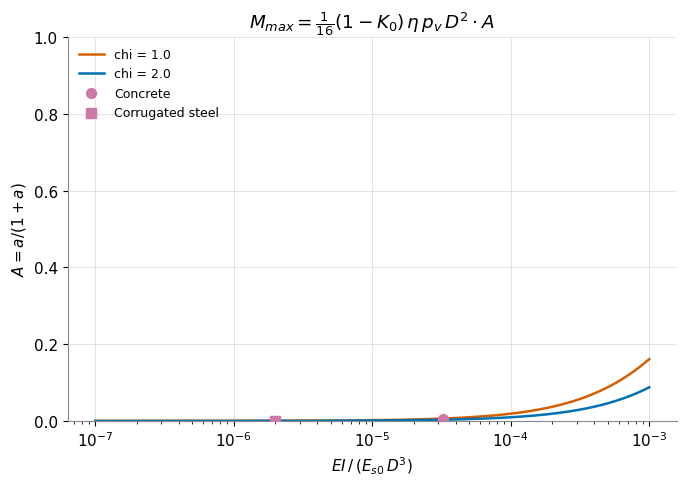

In [17]:
x_ratio = np.logspace(-7, -3, 400)   # EI / (Es0 * D**3), dimensionless

fig, ax = plt.subplots(figsize=(7, 5))
for chi_, color in [(1.0, COLOR_CROWN), (2.0, COLOR_EQUATOR)]:
    a_vals = 192 * x_ratio / chi_
    A_vals = a_vals / (1 + a_vals)
    ax.plot(x_ratio, A_vals, color=color, linewidth=1.8, label=f"chi = {chi_:.1f}")

Es0_ref = plane_strain_modulus(inputs["Es"], inputs["nu_s"])
for label, res, marker in [("Concrete", results, "o"), ("Corrugated steel", results_steel, "s")]:
    x_pt = res["EI"] / (Es0_ref * inputs["D"] ** 3)
    A_pt = res["a"] / (1 + res["a"])
    ax.scatter([x_pt], [A_pt], color=COLOR_CAPACITY, zorder=5, s=50, marker=marker, label=label)

ax.set_xscale("log")
ax.set_xlabel(r"$EI\,/\,(E_{s0}\,D^3)$")
ax.set_ylabel(r"$A = a/(1+a)$")
ax.set_title(r"$M_{max} = \frac{1}{16}(1-K_0)\,\eta\,p_v\,D^2\cdot A$")
ax.legend(loc="upper left", fontsize=9, frameon=False)
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

## 13. Sensitivity analysis

Using the Configuration-A (concrete) parameters as a base case, sweep the
**lining flexural stiffness** $EI$ and the **overburden** $H$ to see how the
structural loads respond. Both sweeps re-evaluate the full `evaluate_lining`
workflow — no new formulas are introduced.

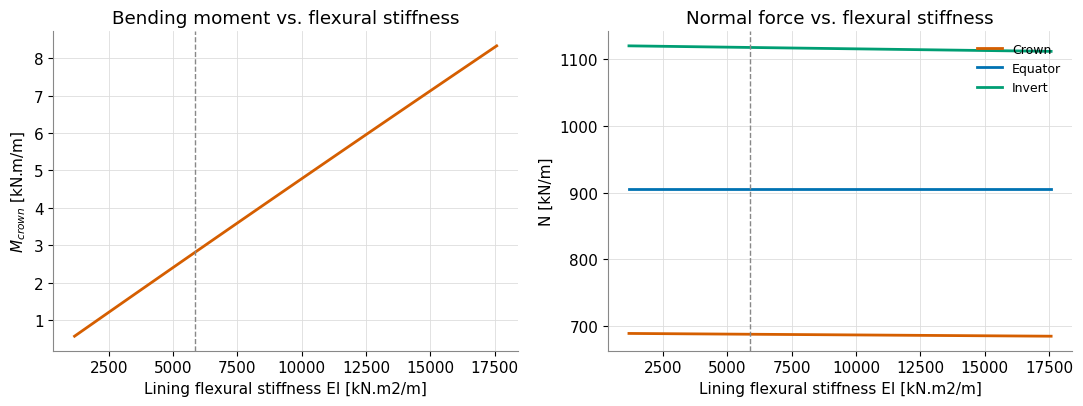

In [18]:
def _sweep_concrete(key, values):
    rows = []
    for v in values:
        p = dict(inputs)
        p[key] = v
        r = evaluate_lining(kind="concrete", D=p["D"], H=p["H"], gamma=p["gamma"], q=p["q"],
                             K0=p["K0"], eta=p["eta"], Es=p["Es"], nu_s=p["nu_s"], chi=p["chi"],
                             EI=p["EI"], EA=p["EA"])
        rows.append({key: v, "M_crown": r["M_crown"], "N_crown": r["N_crown"],
                     "N_equator": r["N_equator"], "N_invert": r["N_invert"]})
    return pd.DataFrame(rows)


EI_range = np.linspace(0.2 * inputs["EI"], 3.0 * inputs["EI"], 60)
df_EI = _sweep_concrete("EI", EI_range)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(df_EI["EI"], df_EI["M_crown"], color=COLOR_CROWN, linewidth=2)
axes[0].axvline(inputs["EI"], color="#888888", linewidth=1, linestyle="--")
axes[0].set_xlabel("Lining flexural stiffness EI [kN.m2/m]")
axes[0].set_ylabel(r"$M_{crown}$ [kN.m/m]")
axes[0].set_title("Bending moment vs. flexural stiffness")

axes[1].plot(df_EI["EI"], df_EI["N_crown"], color=COLOR_CROWN, linewidth=2, label="Crown")
axes[1].plot(df_EI["EI"], df_EI["N_equator"], color=COLOR_EQUATOR, linewidth=2, label="Equator")
axes[1].plot(df_EI["EI"], df_EI["N_invert"], color=COLOR_INVERT, linewidth=2, label="Invert")
axes[1].axvline(inputs["EI"], color="#888888", linewidth=1, linestyle="--")
axes[1].set_xlabel("Lining flexural stiffness EI [kN.m2/m]")
axes[1].set_ylabel("N [kN/m]")
axes[1].set_title("Normal force vs. flexural stiffness")
axes[1].legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

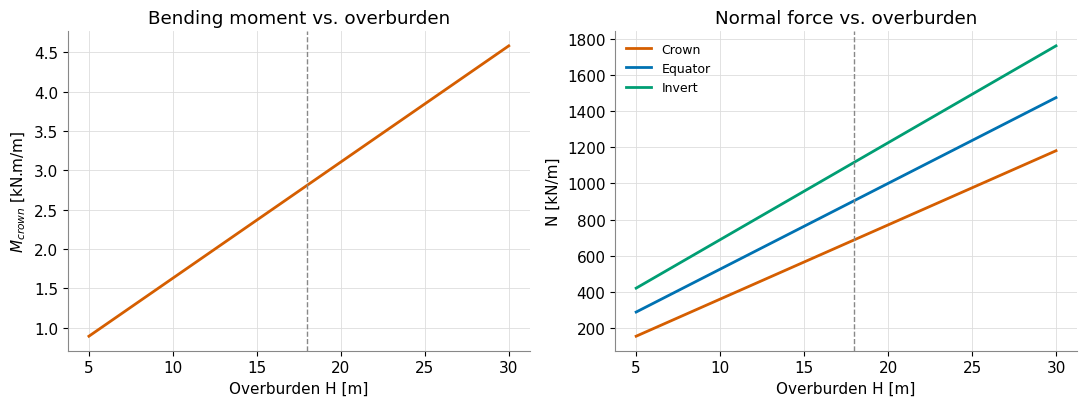

In [19]:
H_range = np.linspace(5, 30, 60)
df_H = _sweep_concrete("H", H_range)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(df_H["H"], df_H["M_crown"], color=COLOR_CROWN, linewidth=2)
axes[0].axvline(inputs["H"], color="#888888", linewidth=1, linestyle="--")
axes[0].set_xlabel("Overburden H [m]")
axes[0].set_ylabel(r"$M_{crown}$ [kN.m/m]")
axes[0].set_title("Bending moment vs. overburden")

axes[1].plot(df_H["H"], df_H["N_crown"], color=COLOR_CROWN, linewidth=2, label="Crown")
axes[1].plot(df_H["H"], df_H["N_equator"], color=COLOR_EQUATOR, linewidth=2, label="Equator")
axes[1].plot(df_H["H"], df_H["N_invert"], color=COLOR_INVERT, linewidth=2, label="Invert")
axes[1].axvline(inputs["H"], color="#888888", linewidth=1, linestyle="--")
axes[1].set_xlabel("Overburden H [m]")
axes[1].set_ylabel("N [kN/m]")
axes[1].set_title("Normal force vs. overburden")
axes[1].legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

## 14. Reference dataset (Table 2 / Table 3 of the source paper)

Transcribed as-published, for context and citation only — **not** recomputed
here, since $E_r$, $\nu_r$, $\nu_s$ and $\gamma$ are not reported per case
(only $E_{s0}$ is). Columns `Nc/Na/Mc/Ma (CF)` are the paper's closed-form
results; `(FEM)` are its finite-element results for the same 7 real tunnels
(all shotcrete/concrete NATM linings — this dataset has no bearing on the
corrugated-steel configuration of §9-11).

In [20]:
table2_3 = pd.DataFrame([
    # H,    D,    d,    e,    q,   K0,  eta,  Es0,  Nc_CF, Nc_FEM, Na_CF, Na_FEM, Mc_CF, Mc_FEM, Ma_CF, Ma_FEM
    [18.0, 10.00,  7.0, 0.15, 20, 0.60, 0.50, 180,  620,  740,  670,  615,  4.8,  2.2,  5.9,  6.5],
    [15.9,  5.45,  4.8, 0.10, 12, 0.60, 0.50, 240,  365,  380,  450,  385,  1.5,  0.5,  1.6,  1.6],
    [11.9, 17.40,  9.4, 0.25, 12, 0.60, 0.50, 180,  720,  500,  680,  780, 10.2, 10.0, 13.8, 65.0],
    [13.4, 18.70, 14.0, 0.30, 12, 0.60, 0.67, 180, 1080, 1070, 1180,  600, 17.0,  8.0, 21.0, 35.0],
    [ 4.9,  5.50,  4.8, 0.10, 12, 0.60, 0.67, 240,  120,  110,  160,  125,  0.5,  0.5,  0.5,  0.9],
    [18.0, 10.00,  7.0, 0.15, 20, 0.60, 0.67, 180,  825,  905,  870,  955,  6.4,  2.0,  7.9,  2.5],
    [14.6, 18.00, 10.0, 0.25, 20, 0.60, 0.67, 180, 1070,  985, 1025, 1235, 18.0,  6.9, 24.2, 67.0],
], columns=["H", "D", "d", "e", "q", "K0", "eta", "Es0",
            "Nc_CF", "Nc_FEM", "Na_CF", "Na_FEM", "Mc_CF", "Mc_FEM", "Ma_CF", "Ma_FEM"],
   index=pd.RangeIndex(1, 8, name="Case"))
table2_3

,H,D,d,e,q,K0,eta,Es0,Nc_CF,Nc_FEM,Na_CF,Na_FEM,Mc_CF,Mc_FEM,Ma_CF,Ma_FEM
Case,,,,,,,,,,,,,,,,
1,18.0,10.00,7.0,0.15,20,0.6,0.50,180,620,740,670,615,4.8,2.2,5.9,6.5
2,15.9,5.45,4.8,0.10,12,0.6,0.50,240,365,380,450,385,1.5,0.5,1.6,1.6
3,11.9,17.40,9.4,0.25,12,0.6,0.50,180,720,500,680,780,10.2,10.0,13.8,65.0
4,13.4,18.70,14.0,0.30,12,0.6,0.67,180,1080,1070,1180,600,17.0,8.0,21.0,35.0
5,4.9,5.50,4.8,0.10,12,0.6,0.67,240,120,110,160,125,0.5,0.5,0.5,0.9
6,18.0,10.00,7.0,0.15,20,0.6,0.67,180,825,905,870,955,6.4,2.0,7.9,2.5
7,14.6,18.00,10.0,0.25,20,0.6,0.67,180,1070,985,1025,1235,18.0,6.9,24.2,67.0


## 15. Capacity checks

- **Concrete**: a full **N-M interaction diagram** (below) — checking axial
  and flexural capacity independently ignores that a heavily-compressed
  section has less spare moment capacity, and vice versa; the interaction
  envelope captures that properly.
- **Corrugated steel**: **two independent** checks — plate combined stress
  ($\sigma_{max}$, §9, max of crown/equator) vs. yield $F_y$, and
  bolted-seam thrust ($N_{max}$) vs. the seam's rated capacity. In practice
  the seam is very often governing; both are reported so neither is
  silently ignored.

All capacity values below are **illustrative placeholders only** — replace
with values from an actual N-M interaction check per the applicable design
code (concrete) or the manufacturer's tested/rated properties (corrugated
steel) before using this for a real design decision.

In [21]:
Fy_default = 230_000.0          # kPa (230 MPa), typical AASHTO M167/ASTM A761 structural-plate steel
seam_capacity_default = 1_750.0 # kN/m -- PLACEHOLDER (heavy-duty multi-row bolted seam, large-diameter
                                 # structural plate); confirm against the selected product's rated seam strength

print("Corrugated steel configuration")
print(f"  sigma_max = {results_steel['sigma_max']:.1f} kPa   Fy = {Fy_default:.0f} kPa"
      f"   utilization (yield)= {results_steel['sigma_max']/Fy_default:.2f}")
print(f"  N_max     = {results_steel['N_max']:.1f} kN/m   seam capacity = {seam_capacity_default:.0f} kN/m"
      f"   utilization (seam) = {results_steel['N_max']/seam_capacity_default:.2f}")

Corrugated steel configuration
  sigma_max = 143004.8 kPa   Fy = 230000 kPa   utilization (yield)= 0.62
  N_max     = 1120.6 kN/m   seam capacity = 1750 kN/m   utilization (seam) = 0.64


### N-M interaction diagram (concrete)

A simplified, piecewise-linear ("rhomboid") capacity envelope in $N$-$M$
space, defined by four vertices:

- $(N_{cap}^-,\,0)$ — pure tension capacity (this notebook keeps its
  established **compression-positive** sign convention throughout, so
  tension capacity is $\le 0$; it defaults to $0$, i.e. no tensile
  capacity assumed for an unreinforced/lightly-reinforced section).
- $(N_{cap}^+,\,0)$ — pure compression capacity ("squash load").
- $(N_p,\,M_p)$ and $(N_p,\,-M_p)$ — the two corners, i.e. the maximum
  moment capacity $M_p$, attained at some intermediate axial force $N_p$
  (both directions, matching crown $+M$/equator $-M$ of equal magnitude).

Between vertices the boundary is linear, so the **available moment capacity
at a given axial force** $N$ is a simple two-segment interpolation. A point
$(N,M)$ is safe iff $N_{cap}^-\le N\le N_{cap}^+$ and $|M|$ is below that
boundary — checked at all three ring locations (crown, equator, invert;
$M=0$ at the invert by construction, §7).

Crown    N=   687.8 kN/m   M=+2.811 kN.m/m   M_capacity=4.422 kN.m/m   utilization=0.64
Equator  N=   905.0 kN/m   M=-2.811 kN.m/m   M_capacity=3.347 kN.m/m   utilization=0.84
Invert   N=  1117.7 kN/m   M=+0.000 kN.m/m   M_capacity=2.151 kN.m/m   utilization=0.00


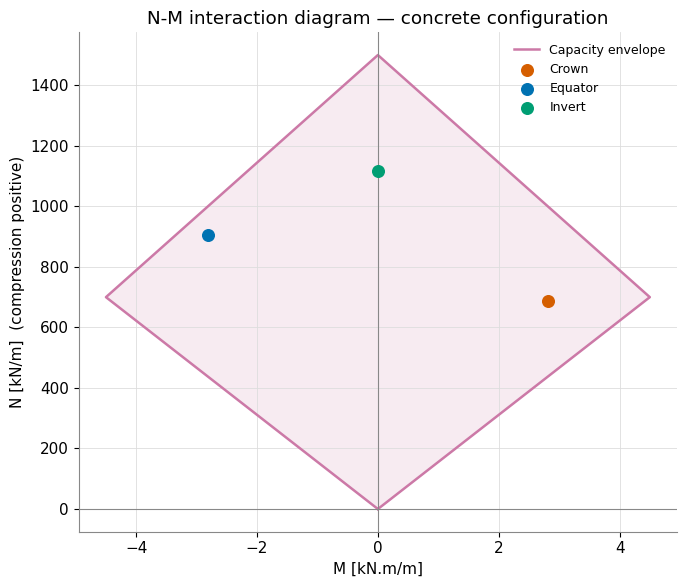

In [22]:
N_tension_cap_default = 0.0      # kN/m -- no tensile capacity assumed (unreinforced/lightly-reinforced)
N_compression_cap_default = 1_500.0  # kN/m -- PLACEHOLDER squash load; replace with an actual capacity check
Np_default = 700.0                   # kN/m -- PLACEHOLDER axial force at peak moment capacity
Mp_default = 4.5                     # kN.m/m -- PLACEHOLDER peak moment capacity


def M_capacity(N, N_tension_cap, N_compression_cap, Np, Mp):
    """Available |M| capacity at axial force N, from the rhomboid envelope
    with vertices (N_tension_cap,0), (Np,Mp), (N_compression_cap,0),
    (Np,-Mp). Zero (no moment capacity at all) once N itself is outside
    [N_tension_cap, N_compression_cap]."""
    N = np.asarray(N, dtype=float)
    left = Mp * (N - N_tension_cap) / (Np - N_tension_cap)
    right = Mp * (N_compression_cap - N) / (N_compression_cap - Np)
    Mcap = np.where(N <= Np, left, right)
    return np.where((N < N_tension_cap) | (N > N_compression_cap), 0.0, Mcap)


rhomboid = np.array([
    [N_tension_cap_default, 0.0], [Np_default, Mp_default],
    [N_compression_cap_default, 0.0], [Np_default, -Mp_default], [N_tension_cap_default, 0.0],
])

fig, ax = plt.subplots(figsize=(7, 6))
ax.fill(rhomboid[:, 1], rhomboid[:, 0], color=COLOR_CAPACITY, alpha=0.15)
ax.plot(rhomboid[:, 1], rhomboid[:, 0], color=COLOR_CAPACITY, linewidth=1.8, label="Capacity envelope")

demand = [("Crown", results["N_crown"], results["M_crown"], COLOR_CROWN),
          ("Equator", results["N_equator"], results["M_equator"], COLOR_EQUATOR),
          ("Invert", results["N_invert"], 0.0, COLOR_INVERT)]
for label, N_d, M_d, color in demand:
    ax.scatter([M_d], [N_d], color=color, s=70, zorder=5, label=label)
    Mcap_d = M_capacity(N_d, N_tension_cap_default, N_compression_cap_default, Np_default, Mp_default)
    util = abs(M_d) / Mcap_d if Mcap_d > 0 else np.inf
    print(f"{label:8s} N={N_d:8.1f} kN/m   M={M_d:+6.3f} kN.m/m   "
          f"M_capacity={Mcap_d:5.3f} kN.m/m   utilization={util:.2f}")

ax.set_xlabel("M [kN.m/m]")
ax.set_ylabel("N [kN/m]  (compression positive)")
ax.set_title("N-M interaction diagram — concrete configuration")
ax.axhline(0, color="#888888", linewidth=0.8)
ax.axvline(0, color="#888888", linewidth=0.8)
ax.legend(frameon=False, loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

## 16. Notes and limitations

- Valid for **circular** linings, **no water pressure**, and soils exhibiting
  **little plastic yielding** (immediate shotcrete support). For elliptical
  shapes or water pressure, see the extended version of Núñez (2000).
- $\eta$ (stress relaxation): recommended $1/3$–$2/3$ for primary (temporary)
  supports, $1.0$ for permanent linings; Eq. 8 gives a theoretical estimate
  from the distance to the face.
- $\chi$ (contact roughness / support type): $1.0$ for smooth contacts /
  primary supports, $2.0$ for rough contacts / permanent linings (also used
  here for the mechanically-interlocked corrugated-steel/soil contact).
- $M_{max}$ (Eq. 21/22) is applied with **equal magnitude, opposite sign** at
  crown (+) and equator (−); the source paper's own numerical-vs-closed-form
  comparison (Table 4) shows normal forces match FEM well (ratios mostly
  0.8–1.3) while bending moments scatter more widely, especially for large
  caverns excavated by bench-berm methods — treat $M$ results as
  order-of-magnitude design guidance, cross-checked against FEM for final
  design.
- Eqs. 12-13 (ground displacements) and Eq. 5 (plastic radius) are included
  for completeness but are **not** required by the structural-load workflow
  of §7-8.
- **Corrugated steel is a modelling extrapolation** (§9): the sinusoidal
  section-property approximation and the small-deflection Núñez mechanics
  are both simplifications. Use §9-11/§15 for relative comparison and
  preliminary screening only; verify a selected corrugated-steel design with
  an established flexible-conduit method (Iowa/Spangler, AASHTO LRFD
  Section 12, or CANDE-type FEM) and the manufacturer's actual section/seam
  properties before construction.

# Part II — Probabilistic analysis: FORM and Monte Carlo

Part I treated every input as a fixed, assumed number. In practice every one
of them carries uncertainty — natural spatial/material variability
(aleatory) or limited testing (epistemic) — and that uncertainty propagates
into the computed loads.

This part:

1. Represents **every input as a random variable**, chosen from four standard
   families (uniform, triangular, normal, lognormal) — for **either** lining
   type of §9, selected below with a single switch.
2. Propagates that uncertainty through the closed-form model with **Monte
   Carlo simulation**, to see the resulting spread in $M$ and $N$, and ranks
   inputs by their correlation with the response.
3. Runs a **First-Order Reliability Method (FORM)** analysis on the
   lining's governing capacity check(s) from §15, to get a reliability index
   $\beta$, a probability of exceedance $P_f$, and — most importantly for
   this purpose — **importance factors** $\alpha_i^2$ that partition the
   uncertainty in $P_f$ across the input variables.
4. Combines both rankings into a single view of **which variables most
   deserve refined calibration** (better lab/field data, tighter QA) versus
   which ones barely matter and can safely stay at a rough estimate.

## 17. Random-variable framework

A small `RandomVariable` wrapper around `scipy.stats` covers the four
requested families in one consistent interface, parametrized the way
geotechnical/structural engineers usually think about them:

| Family | Parameters | Notes |
|---|---|---|
| `uniform` | `low, high` | equal likelihood between bounds |
| `triangular` | `low, mode, high` | a most-likely value with bounded spread |
| `normal` | `mean, std` | symmetric, can go negative — avoid for strictly-positive quantities |
| `lognormal` | `mean, std` | strictly positive; `mean`/`std` are of $X$ itself (moment-matched), not of $\ln X$ |

It also implements the **Rosenblatt transform** `to_u` / `from_u` between
physical space and standard-normal space, $U=\Phi^{-1}(F_X(x))$, needed by
FORM below. Input variables are treated as **statistically independent**
(no correlation structure) — see the limitations note in §25.

In [23]:
from scipy import stats
from scipy.optimize import minimize


class RandomVariable:
    """A random variable from one of four families (uniform, triangular,
    normal, lognormal), wrapping scipy.stats, with sampling, PDF/CDF, and
    the (independent-variable) Rosenblatt transform to/from standard
    normal space used by FORM."""

    def __init__(self, name, dist, **params):
        self.name = name
        self.dist = dist
        self.params = params
        if dist == "uniform":
            low, high = params["low"], params["high"]
            self._rv = stats.uniform(loc=low, scale=high - low)
        elif dist == "triangular":
            low, mode, high = params["low"], params["mode"], params["high"]
            c = (mode - low) / (high - low)
            self._rv = stats.triang(c, loc=low, scale=high - low)
        elif dist == "normal":
            mean, std = params["mean"], params["std"]
            self._rv = stats.norm(loc=mean, scale=std)
        elif dist == "lognormal":
            mean, std = params["mean"], params["std"]
            cv = std / mean
            sigma_ln = np.sqrt(np.log(1 + cv ** 2))
            mu_ln = np.log(mean) - 0.5 * sigma_ln ** 2
            self._rv = stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln))
        else:
            raise ValueError(f"Unknown distribution '{dist}' for '{name}'; "
                              f"use uniform, triangular, normal or lognormal.")
        self.mean = float(self._rv.mean())
        self.std = float(self._rv.std())

    def sample(self, n, random_state=None):
        return self._rv.rvs(size=n, random_state=random_state)

    def pdf(self, x):
        return self._rv.pdf(x)

    def cdf(self, x):
        return self._rv.cdf(x)

    def ppf(self, u):
        return self._rv.ppf(u)

    def to_u(self, x):
        """Rosenblatt transform: physical space -> standard normal space."""
        return stats.norm.ppf(np.clip(self.cdf(x), 1e-12, 1 - 1e-12))

    def from_u(self, u):
        """Inverse Rosenblatt transform: standard normal space -> physical space."""
        return self.ppf(stats.norm.cdf(u))

    def __repr__(self):
        p = ", ".join(f"{k}={v:g}" for k, v in self.params.items())
        return f"RandomVariable({self.name!r}, {self.dist!r}, {p})"

## 18. All inputs as random variables

**Pick the lining type here** — everything downstream (Monte Carlo, FORM,
sensitivity ranking) rebuilds itself automatically from this one switch.

- **Geometry/load** ($D,H,\gamma,q,K_0,\eta$) and **soil** ($E_s,\nu_s,\chi$):
  common to both lining types, distributions centered on §10's values.
- **Concrete**: $EI$, $EA$ (lognormal, ~20% CoV each — an aggregate
  stiffness uncertainty, since there's no longer a separate
  thickness/modulus to combine); capacity variables $N_{cap}^+$
  (compression), $N_p$, $M_p$ (§15's interaction-diagram vertices,
  lognormal, ~20% CoV each). $N_{cap}^-$ (tension) stays fixed at $0$ — a
  modelling assumption, not an aleatory quantity.
- **Corrugated steel**: plate thickness $t$ (lognormal, ~8% CoV — mill
  tolerance/corrosion allowance), $E_{steel}$ (normal, tight — steel modulus
  has little real scatter), $\nu_{steel}$ (narrow uniform); capacity
  variables $F_y$ (lognormal, ~8% CoV — mill-certified steel grade) and
  `seam_capacity` (lognormal, ~20% CoV — bolted-connection workmanship).
  Corrugation depth/pitch are a **selected manufactured profile**, not an
  aleatory quantity, so they stay fixed (§10 values).

In [24]:
LINING_TYPE = "concrete"  # "concrete" or "corrugated_steel" -- change this to switch Part II entirely

active_inputs = inputs if LINING_TYPE == "concrete" else inputs_steel

common_vars = {
    "D":     RandomVariable("D", "normal", mean=active_inputs["D"], std=0.05),
    "H":     RandomVariable("H", "normal", mean=active_inputs["H"], std=1.00),
    "gamma": RandomVariable("gamma", "normal", mean=active_inputs["gamma"], std=1.00),
    "q":     RandomVariable("q", "triangular", low=0.0, mode=active_inputs["q"], high=2 * active_inputs["q"]),
    "K0":    RandomVariable("K0", "triangular", low=active_inputs["K0"] - 0.15,
                             mode=active_inputs["K0"], high=active_inputs["K0"] + 0.15),
    "eta":   RandomVariable("eta", "triangular", low=1 / 3, mode=active_inputs["eta"], high=2 / 3),
    "Es":    RandomVariable("Es", "lognormal", mean=active_inputs["Es"], std=0.30 * active_inputs["Es"]),
    "nu_s":  RandomVariable("nu_s", "uniform", low=0.20, high=0.30),
    "chi":   RandomVariable("chi", "uniform", low=1.0, high=2.0),
}

if LINING_TYPE == "concrete":
    section_vars = {
        "EI": RandomVariable("EI", "lognormal", mean=inputs["EI"], std=0.20 * inputs["EI"]),
        "EA": RandomVariable("EA", "lognormal", mean=inputs["EA"], std=0.20 * inputs["EA"]),
    }
    capacity_vars = {
        "N_compression_cap": RandomVariable("N_compression_cap", "lognormal",
                                             mean=N_compression_cap_default, std=0.20 * N_compression_cap_default),
        "Np": RandomVariable("Np", "lognormal", mean=Np_default, std=0.20 * Np_default),
        "Mp": RandomVariable("Mp", "lognormal", mean=Mp_default, std=0.20 * Mp_default),
    }
    # N_tension_cap stays FIXED (a modelling assumption, not an aleatory quantity) -- see Sec. 15.
elif LINING_TYPE == "corrugated_steel":
    section_vars = {
        "t":        RandomVariable("t", "lognormal", mean=inputs_steel["t"], std=0.08 * inputs_steel["t"]),
        "Es_steel": RandomVariable("Es_steel", "normal", mean=inputs_steel["Es_steel"], std=0.02 * inputs_steel["Es_steel"]),
        "nu_steel": RandomVariable("nu_steel", "uniform", low=0.27, high=0.33),
    }
    capacity_vars = {
        "Fy":            RandomVariable("Fy", "lognormal", mean=Fy_default, std=0.08 * Fy_default),
        "seam_capacity": RandomVariable("seam_capacity", "lognormal",
                                         mean=seam_capacity_default, std=0.20 * seam_capacity_default),
    }
else:
    raise ValueError(LINING_TYPE)

random_vars = {**common_vars, **section_vars}        # feeds the load model (evaluate_lining)
random_vars_all = {**random_vars, **capacity_vars}    # feeds FORM (adds the capacity variable(s))
STRUCT_VARS = list(random_vars.keys())

basis_common = {
    "D": "as-built survey tolerance", "H": "topographic + design overburden uncertainty",
    "gamma": "lab unit-weight scatter", "q": "surcharge load uncertainty (0 to 2x nominal)",
    "K0": "judgment-based range around assumed value", "eta": "paper's own recommended range for primary supports",
    "Es": "soil stiffness scatter (~30% CoV)", "nu_s": "Table 1 range of the source paper (0.20-0.30)",
    "chi": "full documented smooth-to-rough range",
}
basis_concrete = {
    "EI": "aggregate flexural-stiffness uncertainty (~20% CoV)", "EA": "aggregate normal-stiffness uncertainty (~20% CoV)",
    "N_compression_cap": "squash-load placeholder pending an actual capacity check (~20% CoV); FORM capacity variable (Sec. 21)",
    "Np": "interaction-diagram corner placeholder (~20% CoV); FORM capacity variable (Sec. 21)",
    "Mp": "interaction-diagram corner placeholder (~20% CoV); FORM capacity variable (Sec. 21)",
}
basis_steel = {
    "t": "mill tolerance / corrosion allowance (~8% CoV)", "Es_steel": "steel modulus has little real scatter (~2% CoV)",
    "nu_steel": "narrow plausible range for structural steel",
    "Fy": "mill-certified steel grade scatter (~8% CoV); FORM capacity variable (Sec. 21)",
    "seam_capacity": "bolted-connection workmanship/testing scatter (~20% CoV); FORM capacity variable (Sec. 21)",
}
basis = {**basis_common, **(basis_concrete if LINING_TYPE == "concrete" else basis_steel)}

var_table = pd.DataFrame([
    {"Variable": k, "Distribution": rv.dist, "Params": rv.params,
     "Mean": rv.mean, "Std": rv.std, "CoV": rv.std / rv.mean if rv.mean else np.nan,
     "Basis": basis[k]}
    for k, rv in random_vars_all.items()
]).set_index("Variable")
print(f"LINING_TYPE = {LINING_TYPE!r}")
var_table

LINING_TYPE = 'concrete'


,Distribution,Params,Mean,Std,CoV,Basis
Variable,,,,,,
D,normal,"{'mean': 10.0, 'std': 0.05}",10.000,0.050000,0.005000,as-built survey tolerance
H,normal,"{'mean': 18.0, 'std': 1.0}",18.000,1.000000,0.055556,topographic + design overburden uncertainty
gamma,normal,"{'mean': 19.0, 'std': 1.0}",19.000,1.000000,0.052632,lab unit-weight scatter
q,triangular,"{'low': 0.0, 'mode': 20.0, 'high': 40.0}",20.000,8.164966,0.408248,surcharge load uncertainty (0 to 2x nominal)
K0,triangular,"{'low': 0.44999999999999996, 'mode': 0.6, 'hig...",0.600,0.061237,0.102062,judgment-based range around assumed value
eta,triangular,"{'low': 0.3333333333333333, 'mode': 0.5, 'high...",0.500,0.068041,0.136083,paper's own recommended range for primary supp...
Es,lognormal,"{'mean': 168750.0, 'std': 50625.0}",168750.000,50625.000000,0.300000,soil stiffness scatter (~30% CoV)
nu_s,uniform,"{'low': 0.2, 'high': 0.3}",0.250,0.028868,0.115470,Table 1 range of the source paper (0.20-0.30)
chi,uniform,"{'low': 1.0, 'high': 2.0}",1.500,0.288675,0.192450,full documented smooth-to-rough range


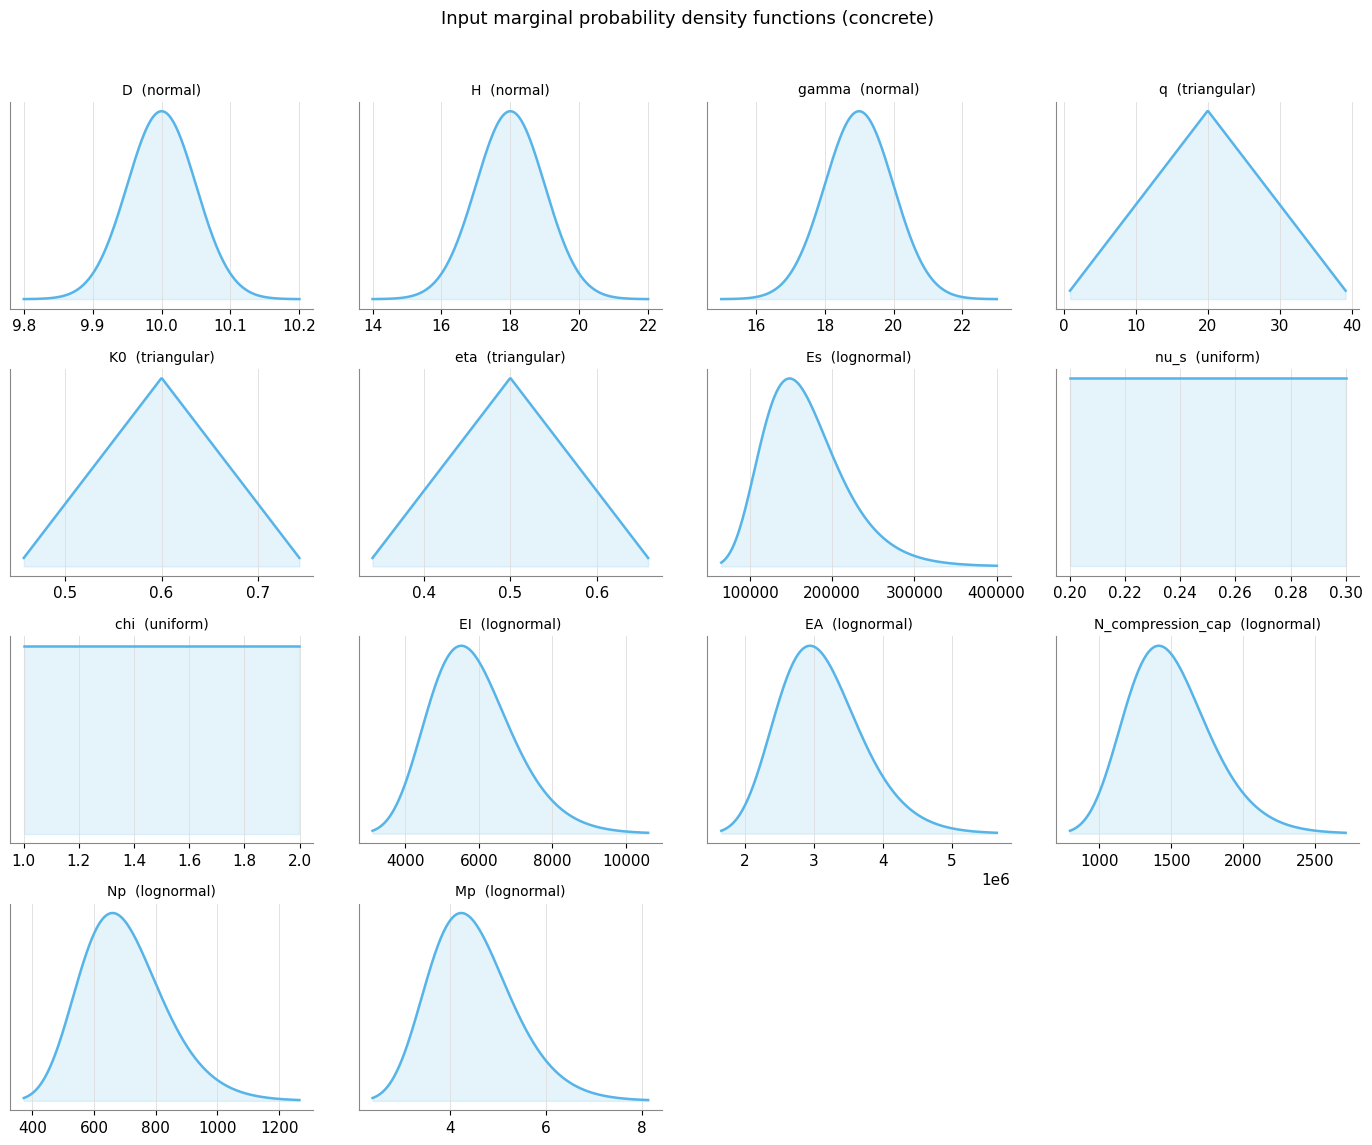

In [25]:
n_vars = len(random_vars_all)
ncols = 4
nrows = -(-n_vars // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.8 * nrows))
axes = axes.ravel()
COLOR_INPUT = "#56B4E9"  # sky blue (Okabe-Ito), consistent "input variable" hue

for ax, (name, rv) in zip(axes, random_vars_all.items()):
    lo = rv.ppf(0.001) if rv.dist != "normal" else rv.mean - 4 * rv.std
    hi = rv.ppf(0.999) if rv.dist != "normal" else rv.mean + 4 * rv.std
    xs = np.linspace(lo, hi, 300)
    ax.plot(xs, rv.pdf(xs), color=COLOR_INPUT, linewidth=1.8)
    ax.fill_between(xs, rv.pdf(xs), color=COLOR_INPUT, alpha=0.15)
    ax.set_title(f"{name}  ({rv.dist})", fontsize=10)
    ax.set_yticks([])

for ax in axes[n_vars:]:
    ax.axis("off")

fig.suptitle(f"Input marginal probability density functions ({LINING_TYPE})", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## 19. Monte Carlo simulation of structural loads

`evaluate_lining` is pure array arithmetic (no branching), so it vectorizes
over Monte Carlo samples with no code changes.

In [26]:
N_MC = 20_000

mc_df = pd.DataFrame({
    name: random_vars[name].sample(N_MC, random_state=1000 + i)
    for i, name in enumerate(STRUCT_VARS)
})

section_kwargs = {k: mc_df[k].values for k in section_vars}
if LINING_TYPE == "corrugated_steel":
    section_kwargs["corr_depth"] = inputs_steel["corr_depth"]
    section_kwargs["corr_pitch"] = inputs_steel["corr_pitch"]

mc_out = evaluate_lining(D=mc_df["D"].values, H=mc_df["H"].values, gamma=mc_df["gamma"].values,
                          q=mc_df["q"].values, K0=mc_df["K0"].values, eta=mc_df["eta"].values,
                          Es=mc_df["Es"].values, nu_s=mc_df["nu_s"].values, chi=mc_df["chi"].values,
                          kind=LINING_TYPE, **section_kwargs)
# Copy every numeric output (the set of keys depends on LINING_TYPE, e.g.
# only corrugated steel has sigma_max/A/W/I -- see evaluate_lining, Sec. 9).
for key, val in mc_out.items():
    if key != "kind":
        mc_df[key] = val

if LINING_TYPE == "concrete":
    # Per-location utilization against the NOMINAL (non-random) interaction
    # envelope of Sec. 15 -- a fixed-shape combination of N and M, analogous
    # to how sigma_max fixes a stress-combination formula for corrugated
    # steel. Purely a sensitivity-analysis convenience column.
    mc_df["utilization_crown"] = np.abs(mc_df["M_crown"]) / M_capacity(
        mc_df["N_crown"], N_tension_cap_default, N_compression_cap_default, Np_default, Mp_default)
    mc_df["utilization_equator"] = np.abs(mc_df["M_equator"]) / M_capacity(
        mc_df["N_equator"], N_tension_cap_default, N_compression_cap_default, Np_default, Mp_default)

mc_df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
D,20000.0,10.000,0.050,9.803,9.965,10.000,10.034,10.183
H,20000.0,18.011,1.000,14.020,17.338,18.019,18.684,21.773
gamma,20000.0,18.983,1.000,15.079,18.303,18.985,19.657,22.934
q,20000.0,20.024,8.229,0.123,14.042,20.040,26.015,39.900
K0,20000.0,0.600,0.061,0.452,0.556,0.600,0.644,0.748
eta,20000.0,0.501,0.068,0.334,0.451,0.501,0.550,0.666
Es,20000.0,167995.914,49897.720,50915.284,132613.603,161089.903,196008.511,509817.527
nu_s,20000.0,0.250,0.029,0.200,0.225,0.250,0.275,0.300
chi,20000.0,1.500,0.290,1.000,1.247,1.498,1.753,2.000
EI,20000.0,5854.917,1167.354,2708.400,5029.099,5736.701,6553.944,11830.246


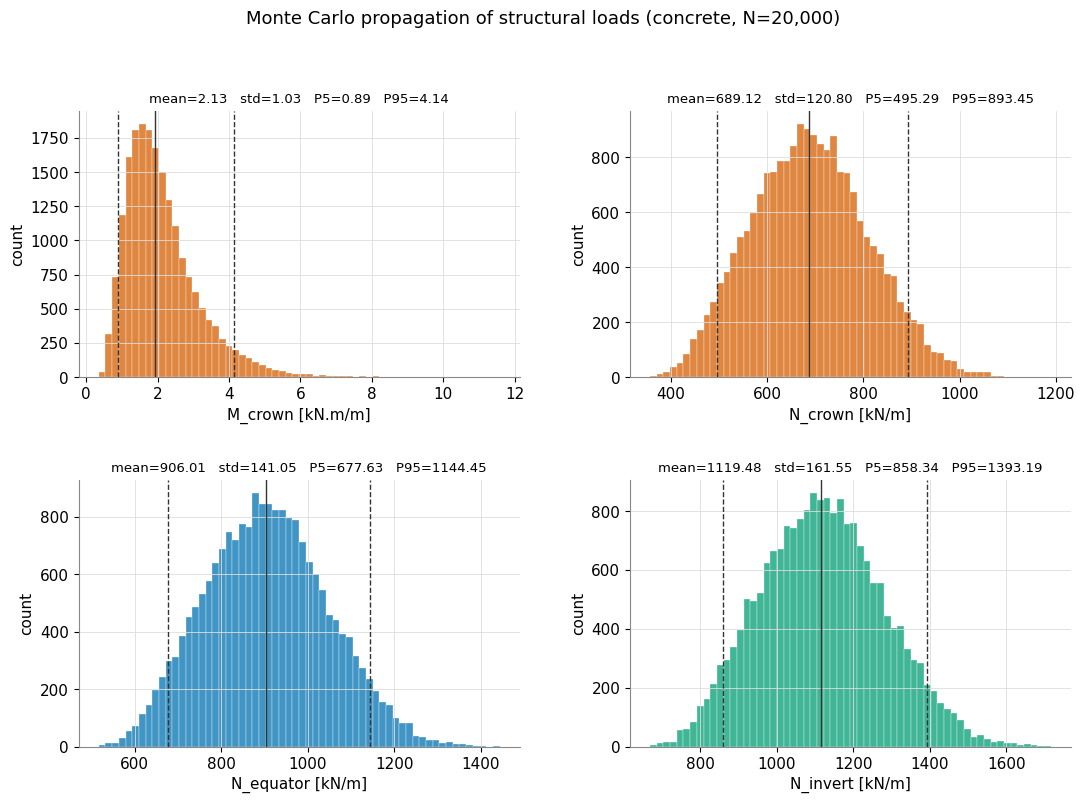

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
panels = [("M_crown", COLOR_CROWN, "M_crown [kN.m/m]"),
          ("N_crown", COLOR_CROWN, "N_crown [kN/m]"),
          ("N_equator", COLOR_EQUATOR, "N_equator [kN/m]"),
          ("N_invert", COLOR_INVERT, "N_invert [kN/m]")]

for ax, (col, color, label) in zip(axes.ravel(), panels):
    data = mc_df[col]
    ax.hist(data, bins=60, color=color, alpha=0.75, edgecolor="white", linewidth=0.3)
    for q_, ls in [(0.05, "--"), (0.5, "-"), (0.95, "--")]:
        ax.axvline(data.quantile(q_), color="#333333", linewidth=1, linestyle=ls)
    ax.set_xlabel(label)
    ax.set_ylabel("count")
    ax.set_title(f"mean={data.mean():.2f}   std={data.std():.2f}   "
                 f"P5={data.quantile(0.05):.2f}   P95={data.quantile(0.95):.2f}", fontsize=9.5)

fig.suptitle(f"Monte Carlo propagation of structural loads ({LINING_TYPE}, N={N_MC:,})", y=1.0, fontsize=13)
fig.tight_layout(w_pad=3.0, h_pad=2.5, rect=[0, 0, 1, 0.96])
plt.show()

## 20. Monte Carlo sensitivity analysis — which inputs drive the spread?

**Spearman rank correlation** between each input and each output is a
robust, distribution-free sensitivity measure (no assumption of linearity).
Values close to $\pm 1$ mean that variable strongly drives that output's
variability; values near 0 mean it barely matters. `M_abs_max`/`N_max` (and
`sigma_max` for corrugated steel) are included because they map directly
onto the capacity checks of §21.

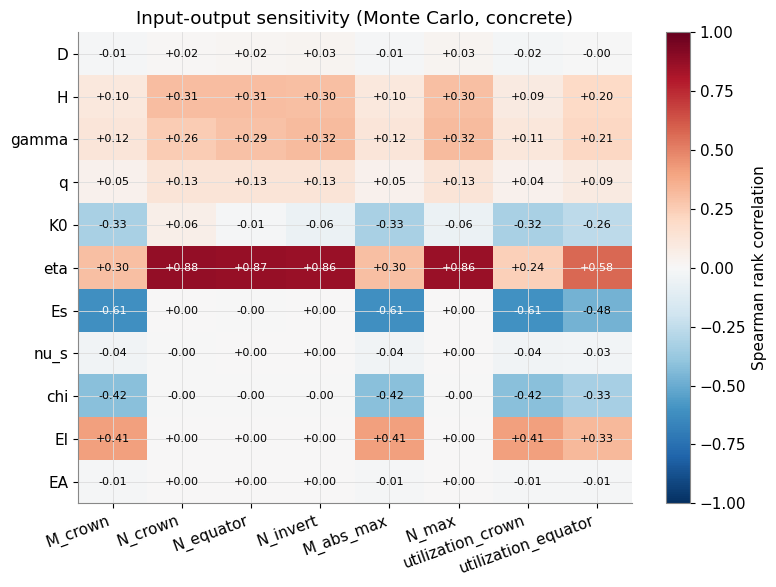

In [28]:
outputs = [c for c in ["M_crown", "N_crown", "N_equator", "N_invert", "M_abs_max", "N_max", "sigma_max",
                        "utilization_crown", "utilization_equator"]
           if c in mc_df.columns]
corr = pd.DataFrame({out: [stats.spearmanr(mc_df[v], mc_df[out]).correlation for v in STRUCT_VARS]
                      for out in outputs}, index=STRUCT_VARS)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(outputs))); ax.set_xticklabels(outputs, rotation=20, ha="right")
ax.set_yticks(range(len(STRUCT_VARS))); ax.set_yticklabels(STRUCT_VARS)
for i in range(len(STRUCT_VARS)):
    for j in range(len(outputs)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.55 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="Spearman rank correlation")
ax.set_title(f"Input-output sensitivity (Monte Carlo, {LINING_TYPE})")
fig.tight_layout()
plt.show()

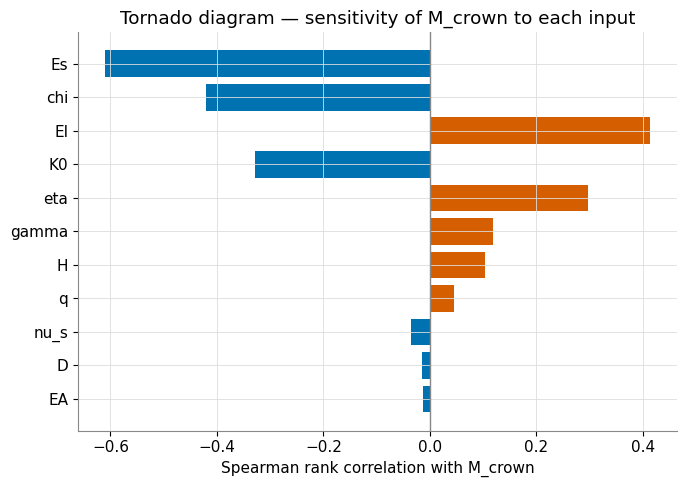

In [29]:
rank = corr["M_crown"].abs().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
colors = [COLOR_CROWN if v >= 0 else COLOR_EQUATOR for v in corr.loc[rank.index, "M_crown"]]
ax.barh(rank.index, corr.loc[rank.index, "M_crown"], color=colors)
ax.axvline(0, color="#888888", linewidth=1)
ax.set_xlabel("Spearman rank correlation with M_crown")
ax.set_title("Tornado diagram — sensitivity of M_crown to each input")
fig.tight_layout()
plt.show()

## 21. FORM — limit state(s) and solver

FORM needs a **limit state function** $g(\mathbf{X})$, with $g>0$ "safe" and
$g<0$ "failure" (exceedance). The governing capacity check(s) of §15 are used
directly, and **each lining type gets several independent limit states**,
each analyzed separately (not combined into one system limit state, so that
each failure mode's own importance factors stay interpretable):

- **Concrete** — the N-M interaction check ($g=M_{capacity}(N)-|M|$, §15's
  `M_capacity`) at the crown and equator; at the invert, $M=0$ always
  (§7), so the interaction check there collapses to a plain axial check,
  $g=N_{cap}^+-N_{invert}$, used directly instead (mathematically
  equivalent, but well-posed for FORM — routing a moment-free location
  through the general formula leaves a degenerate direction where $g\to0$
  as $M_p\to0$ with no physical meaning).
- **Corrugated steel** — plate yield, $g_1=F_y-\sigma_{max}$, and
  bolted-seam thrust, $g_2=\text{seam capacity}-N_{max}$.

**These are simplified stress/thrust checks for demonstrating the
reliability workflow, not code-compliant ULS/SLS design checks** (no
reinforcement/lattice girders, M-N interaction diagrams, tension limits,
creep, buckling, etc.) — treat $\beta$ and $P_f$ below as illustrative.

FORM is solved as the standard constrained-optimization problem — minimize
$\|\mathbf{u}\|$ subject to $g(\mathbf{u})=0$ in standard-normal space — via
SLSQP. (An initial Hasofer-Lind-Rackwitz-Fiessler iteration was tried first
but oscillated on this curved limit-state surface, a known HLRF failure
mode; the optimization formulation converges cleanly and was validated
against the closed-form linear-normal case $g=R-S$ before use here.)

In [30]:
def build_limit_states(kind):
    """Returns {name: (g, rvs)} for the governing capacity check(s) of the
    chosen lining type. Each g is a function only of its OWN relevant random
    variables (rvs) -- e.g. the seam check never sees Fy and vice versa.
    Including an irrelevant variable (zero gradient for that g) in the FORM
    search space causes SLSQP rank-deficiency, so the two checks are kept
    strictly separate rather than sharing random_vars_all."""
    if kind == "concrete":
        def _g_interaction(N_key, M_val, **x):
            x = dict(x)
            N_compression_cap = x.pop("N_compression_cap")
            Np = x.pop("Np")
            Mp = x.pop("Mp")
            r = evaluate_lining(kind="concrete", **x)
            Mcap = M_capacity(r[N_key], N_tension_cap_default, N_compression_cap, Np, Mp)
            return Mcap - np.abs(M_val(r))

        def g_crown(**x):
            return _g_interaction("N_crown", lambda r: r["M_crown"], **x)

        def g_equator(**x):
            return _g_interaction("N_equator", lambda r: r["M_equator"], **x)

        def g_invert(**x):
            # M=0 at the invert BY CONSTRUCTION (Sec. 7), so this reduces to
            # a pure axial check. Routing it through M_capacity(N,...)-0 like
            # the other two locations is technically equivalent but leaves a
            # degenerate direction for FORM to find (g->0 as Mp->0, with no
            # physical meaning) -- checked directly against N_compression_cap
            # instead, which is both simpler and numerically well-posed.
            x = dict(x)
            N_compression_cap = x.pop("N_compression_cap")
            r = evaluate_lining(kind="concrete", **x)
            return N_compression_cap - r["N_invert"]

        rvs_interaction = {**random_vars, "N_compression_cap": capacity_vars["N_compression_cap"],
                            "Np": capacity_vars["Np"], "Mp": capacity_vars["Mp"]}
        rvs_invert = {**random_vars, "N_compression_cap": capacity_vars["N_compression_cap"]}
        return {"N-M interaction @ crown": (g_crown, rvs_interaction),
                "N-M interaction @ equator": (g_equator, rvs_interaction),
                "Axial capacity @ invert": (g_invert, rvs_invert)}

    elif kind == "corrugated_steel":
        def g_yield(**x):
            x = dict(x)
            Fy = x.pop("Fy")
            r = evaluate_lining(kind="corrugated_steel", corr_depth=inputs_steel["corr_depth"],
                                 corr_pitch=inputs_steel["corr_pitch"], **x)
            return Fy - r["sigma_max"]

        def g_seam(**x):
            x = dict(x)
            seam_cap = x.pop("seam_capacity")
            r = evaluate_lining(kind="corrugated_steel", corr_depth=inputs_steel["corr_depth"],
                                 corr_pitch=inputs_steel["corr_pitch"], **x)
            return seam_cap - r["N_max"]

        rvs_yield = {**random_vars, "Fy": capacity_vars["Fy"]}
        rvs_seam = {**random_vars, "seam_capacity": capacity_vars["seam_capacity"]}
        return {"Plate yield (Fy)": (g_yield, rvs_yield), "Bolted seam (N_max)": (g_seam, rvs_seam)}

    raise ValueError(kind)


def form_solve(g_func, random_vars_, u_start=None, fd_step=1e-6, maxiter=300):
    """FORM via constrained optimization: minimize ||u|| s.t. g(u)=0 (SLSQP),
    in standard-normal space. Returns beta, Pf, importance factors alpha,
    and the design point in both U- and X-space.

    Uses a CENTRAL-difference gradient: forward differences were accurate
    enough to reach the right design point but left enough numerical noise
    that SLSQP's internal KKT check sometimes reported 'not converged' even
    after the iterate had stopped moving (verified: same beta to 10+ sig.
    figs. either way). Central differences remove that false negative.
    """
    names = list(random_vars_.keys())
    n = len(names)

    def x_from_u(u):
        return {name: random_vars_[name].from_u(u[i]) for i, name in enumerate(names)}

    def g_of_u(u):
        return g_func(**x_from_u(u))

    def grad_g(u):
        grad = np.empty(n)
        for i in range(n):
            step = fd_step * max(abs(u[i]), 1.0)
            u_plus = u.copy(); u_plus[i] += step
            u_minus = u.copy(); u_minus[i] -= step
            grad[i] = (g_of_u(u_plus) - g_of_u(u_minus)) / (2 * step)
        return grad

    u0 = np.zeros(n) if u_start is None else np.array(u_start, dtype=float)
    cons = [{"type": "eq", "fun": g_of_u, "jac": grad_g}]
    opt = minimize(lambda u: 0.5 * np.dot(u, u), u0, jac=lambda u: u,
                   constraints=cons, method="SLSQP",
                   options={"maxiter": maxiter, "ftol": 1e-12})

    u_star = opt.x
    beta = np.linalg.norm(u_star)
    grad = grad_g(u_star)
    alpha = -grad / np.linalg.norm(grad)
    Pf = stats.norm.cdf(-beta)
    return {
        "beta": beta, "Pf": Pf, "alpha": dict(zip(names, alpha)),
        "u_star": dict(zip(names, u_star)), "x_star": x_from_u(u_star),
        "success": opt.success, "message": opt.message, "n_iter": opt.nit,
        "g_at_design_point": g_of_u(u_star),
    }


limit_states = build_limit_states(LINING_TYPE)
list(limit_states.keys())

['N-M interaction @ crown',
 'N-M interaction @ equator',
 'Axial capacity @ invert']

Before solving, a quick sanity check: FORM's usual $\beta$/$P_f$ formulas
assume the **nominal (mean-value) design is on the safe side** ($g>0$ at the
mean), and then measure how far a failure boundary is from it. If a limit
state already fails at the mean values, that assumption breaks and the
standard $P_f=\Phi(-\beta)$ reading becomes misleading (this can genuinely
happen — e.g. an under-sized placeholder capacity — and is exactly the kind
of thing worth catching before trusting a reliability number).

In [31]:
for name, (g, rvs) in limit_states.items():
    g_mean = g(**{k: rv.mean for k, rv in rvs.items()})
    status = "OK (safe at mean)" if g_mean > 0 else "*** FAILS AT MEAN VALUES ***"
    print(f"{name:25s} g(mean) = {g_mean:10.3g}   {status}")

N-M interaction @ crown   g(mean) =       2.55   OK (safe at mean)
N-M interaction @ equator g(mean) =       1.47   OK (safe at mean)
Axial capacity @ invert   g(mean) =        381   OK (safe at mean)


## 22. FORM results

$\beta$ is the Hasofer-Lind reliability index (distance from the origin to
the design point in standard-normal space); $P_f=\Phi(-\beta)$ is the
first-order estimate of the probability that demand exceeds capacity.
$\alpha_i^2$ (which sum to 1) is each variable's **share of the uncertainty
in $P_f$** for that failure mode — the key output for this section's
purpose. When there is more than one limit state, the one with the
**lowest $\beta$ (highest $P_f$)** is the **governing** failure mode.

In [32]:
form_results = {name: form_solve(g, rvs) for name, (g, rvs) in limit_states.items()}

for name, res in form_results.items():
    print(f"=== {name} ===")
    print(f"  Converged: {res['success']} ({res['message']}), {res['n_iter']} iterations")
    print(f"  g at design point:  {res['g_at_design_point']:.3e}  (should be ~0)")
    print(f"  beta = {res['beta']:.3f}    Pf = Phi(-beta) = {res['Pf']:.4g}")
    print()

governing_name = min(form_results, key=lambda k: form_results[k]["beta"])
print(f"GOVERNING failure mode: '{governing_name}' (lowest beta / highest Pf)")
print()

governing = form_results[governing_name]
alpha2 = pd.Series({k: v ** 2 for k, v in governing["alpha"].items()}).sort_values(ascending=False)
print(f"Importance factors for the governing mode ('{governing_name}'):")
for k, v in alpha2.items():
    print(f"  {k:15s} alpha = {governing['alpha'][k]:+.4f}   alpha^2 = {v:.4f}  ({v*100:.1f}% of Pf uncertainty)")
print(f"  sum(alpha^2) = {alpha2.sum():.4f}  (should be 1.0)")

=== N-M interaction @ crown ===
  Converged: True (Optimization terminated successfully), 8 iterations
  g at design point:  -7.123e-13  (should be ~0)
  beta = 1.314    Pf = Phi(-beta) = 0.09439

=== N-M interaction @ equator ===
  Converged: True (Optimization terminated successfully), 7 iterations
  g at design point:  -3.109e-15  (should be ~0)
  beta = 0.692    Pf = Phi(-beta) = 0.2446

=== Axial capacity @ invert ===
  Converged: True (Optimization terminated successfully), 6 iterations
  g at design point:  2.274e-13  (should be ~0)
  beta = 1.112    Pf = Phi(-beta) = 0.1331

GOVERNING failure mode: 'N-M interaction @ equator' (lowest beta / highest Pf)

Importance factors for the governing mode ('N-M interaction @ equator'):
  eta             alpha = +0.5712   alpha^2 = 0.3263  (32.6% of Pf uncertainty)
  Es              alpha = -0.3683   alpha^2 = 0.1357  (13.6% of Pf uncertainty)
  chi             alpha = -0.3461   alpha^2 = 0.1198  (12.0% of Pf uncertainty)
  N_compression_c

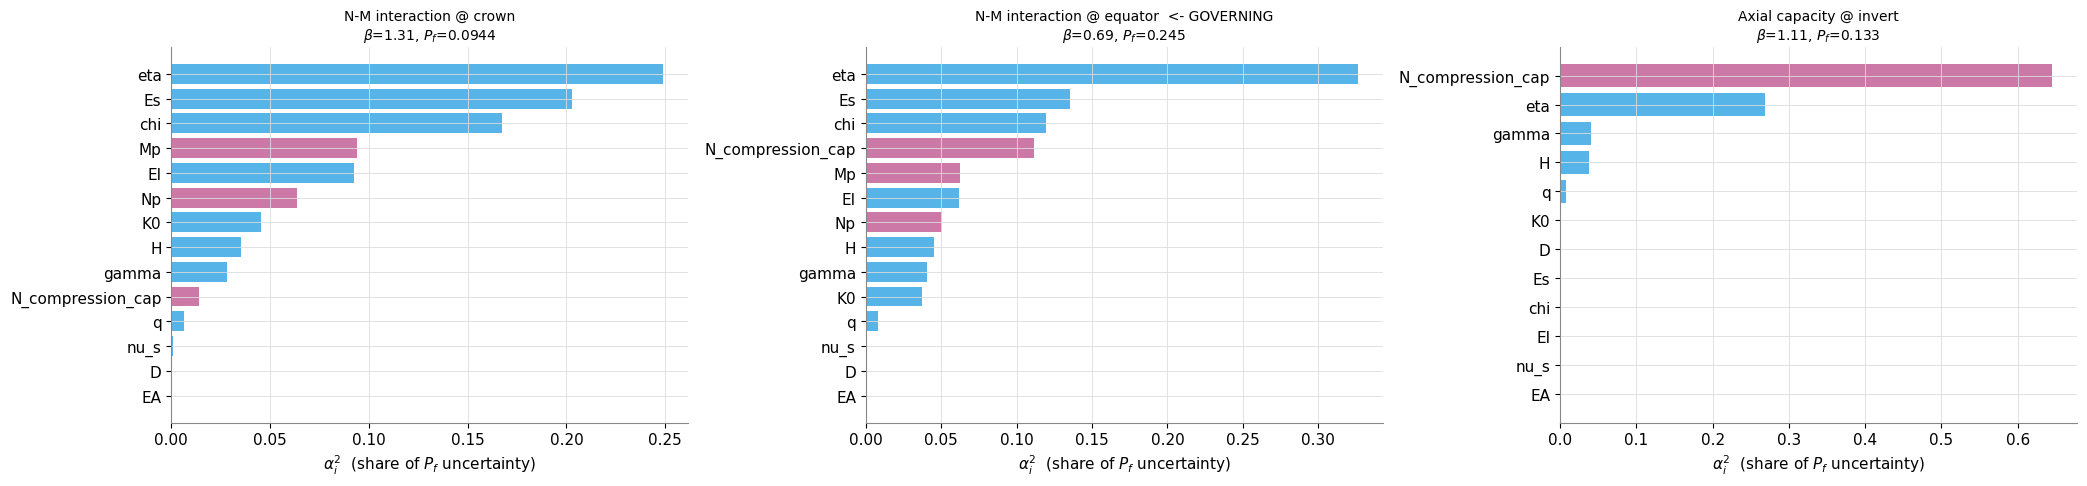

In [33]:
fig, axes = plt.subplots(1, len(form_results), figsize=(7 * len(form_results), 5), squeeze=False)
axes = axes[0]
capacity_var_names = set(capacity_vars.keys())

for ax, (name, res) in zip(axes, form_results.items()):
    a2 = pd.Series({k: v ** 2 for k, v in res["alpha"].items()}).sort_values(ascending=True)
    colors = [COLOR_CAPACITY if k in capacity_var_names else "#56B4E9" for k in a2.index]
    ax.barh(a2.index, a2.values, color=colors)
    ax.set_xlabel(r"$\alpha_i^2$  (share of $P_f$ uncertainty)")
    star = "  <- GOVERNING" if name == governing_name else ""
    ax.set_title(f"{name}{star}\n" + rf"$\beta$={res['beta']:.2f}, $P_f$={res['Pf']:.3g}", fontsize=10)

fig.tight_layout()
plt.show()

## 23. FORM vs. Monte Carlo cross-validation

The full random-variable set (structural + capacity) is resampled and pushed
through each exact limit state $g$ to get a crude Monte Carlo estimate of
$P_f$, as an independent check on FORM (which linearizes $g$ at the design
point — an approximation that is exact only when $g$ is linear in
$\mathbf{U}$-space).

In [34]:
N_MC_g = 200_000
g_df = pd.DataFrame({
    name: random_vars_all[name].sample(N_MC_g, random_state=5000 + i)
    for i, name in enumerate(random_vars_all)
})
g_section_kwargs = {k: g_df[k].values for k in section_vars}
if LINING_TYPE == "corrugated_steel":
    g_section_kwargs["corr_depth"] = inputs_steel["corr_depth"]
    g_section_kwargs["corr_pitch"] = inputs_steel["corr_pitch"]

g_common_kwargs = {k: g_df[k].values for k in common_vars}
g_result = evaluate_lining(kind=LINING_TYPE, **g_common_kwargs, **g_section_kwargs)

for name in limit_states:
    if name in ("N-M interaction @ crown", "N-M interaction @ equator"):
        N_key, M_val = {"N-M interaction @ crown": ("N_crown", g_result["M_crown"]),
                         "N-M interaction @ equator": ("N_equator", g_result["M_equator"])}[name]
        Mcap = M_capacity(g_result[N_key], N_tension_cap_default,
                           g_df["N_compression_cap"].values, g_df["Np"].values, g_df["Mp"].values)
        g_mc = Mcap - np.abs(M_val)
    elif name == "Axial capacity @ invert":
        g_mc = g_df["N_compression_cap"].values - g_result["N_invert"]
    elif name == "Plate yield (Fy)":
        g_mc = g_df["Fy"].values - g_result["sigma_max"]
    elif name == "Bolted seam (N_max)":
        g_mc = g_df["seam_capacity"].values - g_result["N_max"]
    else:
        continue

    pf_mc = np.mean(g_mc < 0)
    cov_pf_mc = np.sqrt((1 - pf_mc) / (pf_mc * N_MC_g)) if pf_mc > 0 else np.nan
    print(f"=== {name} ===")
    print(f"  Pf (FORM)              = {form_results[name]['Pf']:.4g}")
    if pf_mc > 0:
        print(f"  Pf (crude Monte Carlo) = {pf_mc:.4g}   (N={N_MC_g:,}, estimator CoV ~ {cov_pf_mc:.1%})")
    else:
        print(f"  Pf (crude Monte Carlo) = 0  (no exceedances in N={N_MC_g:,} samples)")
    print()

=== N-M interaction @ crown ===
  Pf (FORM)              = 0.09439
  Pf (crude Monte Carlo) = 0.1197   (N=200,000, estimator CoV ~ 0.6%)

=== N-M interaction @ equator ===
  Pf (FORM)              = 0.2446
  Pf (crude Monte Carlo) = 0.2558   (N=200,000, estimator CoV ~ 0.4%)

=== Axial capacity @ invert ===
  Pf (FORM)              = 0.1331
  Pf (crude Monte Carlo) = 0.122   (N=200,000, estimator CoV ~ 0.6%)



## 24. Key variables for refined calibration

Two independent lenses, combined, for the **governing** failure mode
identified in §22:

- **FORM $\alpha_i^2$** — each variable's share of the uncertainty in the
  *reliability index* of the governing capacity check.
- **MC $|\rho_{spearman}|$** — each variable's share of the *raw variance*
  of that check's demand quantity ($N_{max}$ for an axial/seam mode,
  $M_{abs\_max}$ for a flexural mode, $\sigma_{max}$ for plate yield),
  independent of any capacity assumption.

Both are normalized to sum to 1 across the shared structural variables
(excluding capacity variables like $N_{cap}$/$M_{cap}$/$F_y$/`seam_capacity`,
which only enter the FORM side) so they can be read on the same axis. Variables ranking
high on **both** are the strongest, most robust candidates for refined site
investigation, laboratory testing or tighter construction QA; variables
ranking low on both can safely be left at a rough estimate.

In [35]:
demand_column = {"N-M interaction @ crown": "utilization_crown", "N-M interaction @ equator": "utilization_equator",
                  "Axial capacity @ invert": "N_invert",
                  "Plate yield (Fy)": "sigma_max", "Bolted seam (N_max)": "N_max"}[governing_name]
print(f"Governing mode: '{governing_name}'  ->  MC demand quantity used below: '{demand_column}'")

alpha2_struct = pd.Series({k: v for k, v in alpha2.items() if k not in capacity_var_names})
alpha2_norm = alpha2_struct / alpha2_struct.sum()

mc_importance = corr[demand_column].abs()
mc_importance_norm = mc_importance / mc_importance.sum()

key_vars = pd.DataFrame({
    "FORM alpha^2 (normalized)": alpha2_norm,
    "MC |Spearman rho| (normalized)": mc_importance_norm,
}).fillna(0.0)
key_vars["Combined score"] = key_vars.mean(axis=1)
key_vars = key_vars.sort_values("Combined score", ascending=False)
key_vars.round(3)

Governing mode: 'N-M interaction @ equator'  ->  MC demand quantity used below: 'utilization_equator'


,FORM alpha^2 (normalized),MC |Spearman rho| (normalized),Combined score
eta,0.421,0.229,0.325
Es,0.175,0.190,0.182
chi,0.154,0.132,0.143
EI,0.080,0.130,0.105
K0,0.048,0.105,0.076
H,0.058,0.080,0.069
gamma,0.052,0.084,0.068
q,0.011,0.035,0.023
nu_s,0.001,0.011,0.006
EA,0.000,0.004,0.002


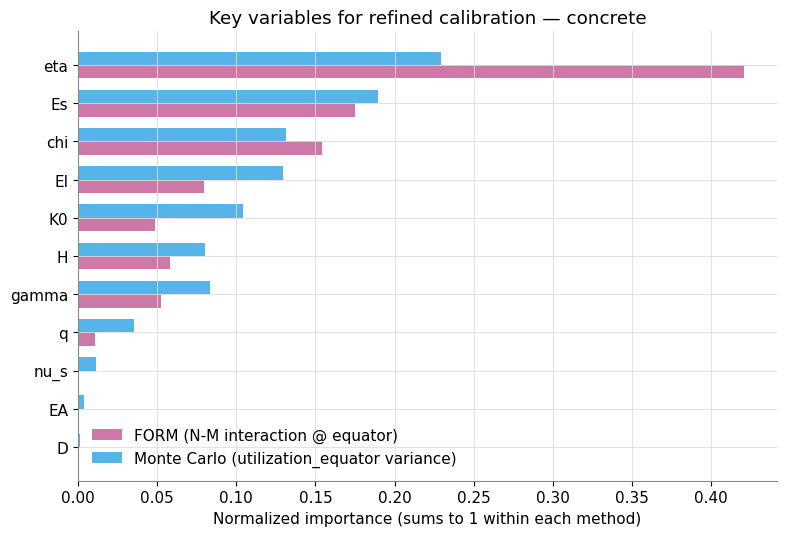

Ranked by combined score (highest priority for refined calibration first):
eta     0.325
Es      0.182
chi     0.143
EI      0.105
K0      0.076
H       0.069
gamma   0.068
q       0.023
nu_s    0.006
EA      0.002
D       0.001


In [36]:
fig, ax = plt.subplots(figsize=(8, 5.5))
idx = key_vars.index
y = np.arange(len(idx))
h = 0.35
ax.barh(y + h / 2, key_vars["FORM alpha^2 (normalized)"], height=h, color=COLOR_CAPACITY,
        label=f"FORM ({governing_name})")
ax.barh(y - h / 2, key_vars["MC |Spearman rho| (normalized)"], height=h, color="#56B4E9",
        label=f"Monte Carlo ({demand_column} variance)")
ax.set_yticks(y); ax.set_yticklabels(idx)
ax.invert_yaxis()
ax.set_xlabel("Normalized importance (sums to 1 within each method)")
ax.set_title(f"Key variables for refined calibration — {LINING_TYPE}")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("Ranked by combined score (highest priority for refined calibration first):")
print(key_vars["Combined score"].to_string(float_format=lambda v: f"{v:.3f}"))

## 25. Notes and limitations — probabilistic analysis

- **Independence assumed.** No correlation structure between inputs is
  modeled (e.g. $E_r$-$E_s$, or $K_0$-$\gamma$ could plausibly correlate in
  reality). A Nataf transform would be the natural extension if correlation
  data becomes available.
- **The FORM limit states (§21) are illustrative**, not code checks: plain
  stress/thrust criteria ignoring reinforcement/lattice girders, M-N
  interaction, tension limits, creep, buckling and long-term strength gain.
  Use them to learn *which variables matter*, not as a pass/fail design
  verification.
- **Multiple failure modes are analyzed as independent components**, not as
  a full system-reliability problem (no Ditlevsen/system bounds combining
  plate-yield and seam failure) — appropriate for ranking variable
  importance per mode, but the *combined* probability of the corrugated
  steel lining failing by either mode is not directly reported.
- **FORM linearizes $g$ at the design point.** For strongly curved or
  multimodal limit states this can bias $P_f$; §23's Monte Carlo cross-check
  is the safeguard — large disagreement between the two would signal that a
  SORM (second-order) correction or importance sampling is warranted.
- **Distribution choices in §18 are illustrative defaults**, not
  site/product-specific data. Replace `random_vars[...]` parameters (and the
  corrugated-steel section/seam properties of §9-10) with project-specific
  statistics before using this for an actual calibration-priority decision.
- Crude Monte Carlo (§23) needs roughly $N \gtrsim 100/P_f$ samples for a
  reasonably precise $P_f$ estimate — for very safe designs ($P_f$ tiny),
  FORM (or variance-reduction MC) is far more efficient than crude MC.